## Code for plotting results from parameter recovery

In [673]:
import dill
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import jax.numpy as jnp
import numpy as np
import pandas as pd
import statsmodels.api as sm

num_trials = 500 # 500, 1000, 2500, 5000
num_iters = 1500 # number of iterations for Gibbs sampler
burn_in = 500 # number of trials thrown away (make sure this is the same as in simulation script)
num_datasets = 50
num_subjects = 50
num_inputs = 3


true_mu_a = 0.98
true_sigma_a = 0.03
true_mu_w = jnp.array([0.0, 0.2, -0.1])
true_sigma_w = jnp.array([1.0, 1.0, 1.0])
true_mu_sigmasq = 0.2
true_beta_sigmasq = 0.5
true_sigma_mu_x = 0.5




In [674]:
sns.set_theme(style="ticks", context="paper",
              font="Arial",
              rc={"font.size": 20,
                "axes.titlesize": 20,
                "axes.labelsize": 20,
                "lines.linewidth": 1.5,
                "xtick.labelsize": 15,
                "ytick.labelsize": 15,
                "xtick.major.size": 5,
                "ytick.major.size": 5,
                "xtick.minor.size": 2,
                "ytick.minor.size": 2,
                "axes.spines.right": False,
                "axes.spines.top": False
        })

In [675]:
"""
Load in dill file (contains the environment when simulation ran on cluster computer)
Due to memory issues on the cluster computer the simulations for high trial counts (2500 and 5000)
had to be split up, simulating the 50 datasets in multiple runs (25/25, or 10/10/10/10/10), hence the multiple dill files.
"""

def load_dill_file(file_path):
    with open(file_path, 'rb') as file:
        list_of_variable_names = dill.load(file)  # Get the names of stored objects
        for variable_name in list_of_variable_names:
            globals()[variable_name] = dill.load(file)  # Get the objects themselves



wd = 'C:/Users/u0141056/OneDrive - KU Leuven/PhD/PROJECTS/CHOICE HISTORY BIAS/Correction slow drifts/hMFC/hMFC/Paper/testing/parameter recovery final/'

file_paths_mapping = {
    (500, 25): [wd + "25subjects_500trials.dil"],
    (500, 50): [wd + "50subjects_500trials.dil"],
    (500, 100): [wd + "100subjects_500trials.dil"],
    (500, 200): [wd + "200subjects_500trials.dil"],
    (1000, 50): [wd + "50subjects_1000trials.dil"],
    (2500, 50): [wd + "50subjects_2500trials1.dil",
                 wd + "50subjects_2500trials2.dil"],
    (5000, 50): [wd + "50subjects_5000trials1.dil",
                 wd + "50subjects_5000trials2.dil",
                 wd + "50subjects_5000trials3.dil",
                 wd + "50subjects_5000trials4.dil",
                 wd + "50subjects_5000trials5.dil"]
}


# Get the file paths based on the number of trials and subjects
which_file = file_paths_mapping.get((num_trials, num_subjects))



# Load in the files
for file_path in which_file:
    load_dill_file(file_path)


# Merge the files in case the 50 datasets were simulated over multiple runs
# 2500 trials in two runs, 5000 trials in five runs
if num_trials == 2500:

    all_true_states = all_true_states + all_true_states2
    all_true_params = all_true_params + all_true_params2
    all_lps = all_lps + all_lps2 
    
    all_posterior_samples_mu_w = all_posterior_samples_mu_w + all_posterior_samples_mu_w2
    all_posterior_samples_sigma_w = all_posterior_samples_sigma_w + all_posterior_samples_sigma_w2
    all_posterior_samples_mu_a = all_posterior_samples_mu_a + all_posterior_samples_mu_a2
    all_posterior_samples_sigma_a = all_posterior_samples_sigma_a + all_posterior_samples_sigma_a2
    all_posterior_samples_mu_sigmasq = all_posterior_samples_mu_sigmasq + all_posterior_samples_mu_sigmasq2
    all_posterior_samples_beta_sigmasq = all_posterior_samples_beta_sigmasq + all_posterior_samples_beta_sigmasq2
    all_posterior_samples_sigma_mu_x = all_posterior_samples_sigma_mu_x + all_posterior_samples_sigma_mu_x2
    
    all_posterior_samples_a = all_posterior_samples_a + all_posterior_samples_a2
    all_posterior_samples_sigmasq = all_posterior_samples_sigmasq + all_posterior_samples_sigmasq2
    all_posterior_samples_w = all_posterior_samples_w + all_posterior_samples_w2
    all_posterior_samples_mu_x = all_posterior_samples_mu_x + all_posterior_samples_mu_x2
    
    # all_posterior_samples_states is already the averaged states over all iterations!
    # due to memory issues on the cluster computer the data before averaging could not be saved away
    # so basically, these are the posterior means of the states on each trial
    all_posterior_samples_states = all_posterior_samples_states + all_posterior_samples_states2 
    

if num_trials == 5000:

    all_true_states = all_true_states + all_true_states2 + all_true_states3 + all_true_states4 + all_true_states5
    all_true_params = all_true_params + all_true_params2 + all_true_params3 + all_true_params4 + all_true_params5
    all_lps = all_lps + all_lps2 + all_lps3 + all_lps4 + all_lps5
    
    all_posterior_samples_mu_w = all_posterior_samples_mu_w + all_posterior_samples_mu_w2 + all_posterior_samples_mu_w3 + all_posterior_samples_mu_w4 + all_posterior_samples_mu_w5
    all_posterior_samples_sigma_w = all_posterior_samples_sigma_w + all_posterior_samples_sigma_w2 + all_posterior_samples_sigma_w3 + all_posterior_samples_sigma_w4 + all_posterior_samples_sigma_w5
    all_posterior_samples_mu_a = all_posterior_samples_mu_a + all_posterior_samples_mu_a2 + all_posterior_samples_mu_a3 + all_posterior_samples_mu_a4 + all_posterior_samples_mu_a5
    all_posterior_samples_sigma_a = all_posterior_samples_sigma_a + all_posterior_samples_sigma_a2 + all_posterior_samples_sigma_a3 + all_posterior_samples_sigma_a4 + all_posterior_samples_sigma_a5
    all_posterior_samples_mu_sigmasq = all_posterior_samples_mu_sigmasq + all_posterior_samples_mu_sigmasq2 + all_posterior_samples_mu_sigmasq3 + all_posterior_samples_mu_sigmasq4 + all_posterior_samples_mu_sigmasq5
    all_posterior_samples_beta_sigmasq = all_posterior_samples_beta_sigmasq + all_posterior_samples_beta_sigmasq2 + all_posterior_samples_beta_sigmasq3 + all_posterior_samples_beta_sigmasq4 + all_posterior_samples_beta_sigmasq5
    all_posterior_samples_sigma_mu_x = all_posterior_samples_sigma_mu_x + all_posterior_samples_sigma_mu_x2 + all_posterior_samples_sigma_mu_x3 + all_posterior_samples_sigma_mu_x4 + all_posterior_samples_sigma_mu_x5
    
    all_posterior_samples_a = all_posterior_samples_a + all_posterior_samples_a2 + all_posterior_samples_a3 + all_posterior_samples_a4 + all_posterior_samples_a5
    all_posterior_samples_sigmasq = all_posterior_samples_sigmasq + all_posterior_samples_sigmasq2 + all_posterior_samples_sigmasq3 + all_posterior_samples_sigmasq4 + all_posterior_samples_sigmasq5
    all_posterior_samples_w = all_posterior_samples_w + all_posterior_samples_w2 + all_posterior_samples_w3 + all_posterior_samples_w4 + all_posterior_samples_w5
    all_posterior_samples_mu_x = all_posterior_samples_mu_x + all_posterior_samples_mu_x2 + all_posterior_samples_mu_x3 + all_posterior_samples_mu_x4 + all_posterior_samples_mu_x5
    
    # all_posterior_samples_states is already the averaged states over all iterations!
    # due to memory issues on the cluster computer the data before averaging could not be saved away
    # so basically, these are the posterior means of the states on each trial
    all_posterior_samples_states = all_posterior_samples_states + all_posterior_samples_states2 + all_posterior_samples_states3 + all_posterior_samples_states4 + all_posterior_samples_states5 
    

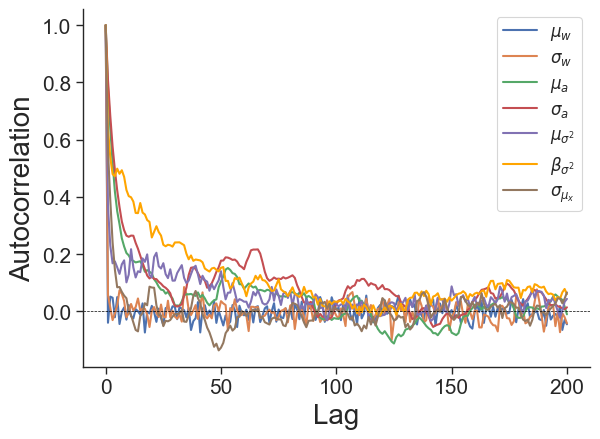

In [629]:
n_lag = 200
dataset = 7

acf_mu_w = sm.tsa.acf(all_posterior_samples_mu_w[dataset][burn_in:, 0], nlags=n_lag)
acf_sigma_w = sm.tsa.acf(all_posterior_samples_sigma_w[dataset][burn_in:, 0], nlags=n_lag)
acf_mu_a = sm.tsa.acf(all_posterior_samples_mu_a[dataset][burn_in:], nlags=n_lag)
acf_sigma_a = sm.tsa.acf(all_posterior_samples_sigma_a[dataset][burn_in:], nlags=n_lag)
acf_mu_sigmasq = sm.tsa.acf(all_posterior_samples_mu_sigmasq[dataset][burn_in:], nlags=n_lag)
acf_beta_sigmasq = sm.tsa.acf(all_posterior_samples_beta_sigmasq[dataset][burn_in:], nlags=n_lag)
acf_sigma_mu_x = sm.tsa.acf(all_posterior_samples_sigma_mu_x[dataset][burn_in:], nlags=n_lag)


plt.plot(acf_mu_w, label=r"$\mu_w$")
plt.plot(acf_sigma_w, label=r"$\sigma_w$")
plt.plot(acf_mu_a, label=r"$\mu_a$")
plt.plot(acf_sigma_a, label=r"$\sigma_a$")
plt.plot(acf_mu_sigmasq, label=r"$\mu_{\sigma^2}$")
plt.plot(acf_beta_sigmasq, label=r"$\beta_{\sigma^2}$", color='orange')
plt.plot(acf_sigma_mu_x, label=r"$\sigma_{\mu_x}$")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("acf_group_params.png", transparent=True, bbox_inches='tight', dpi=600)

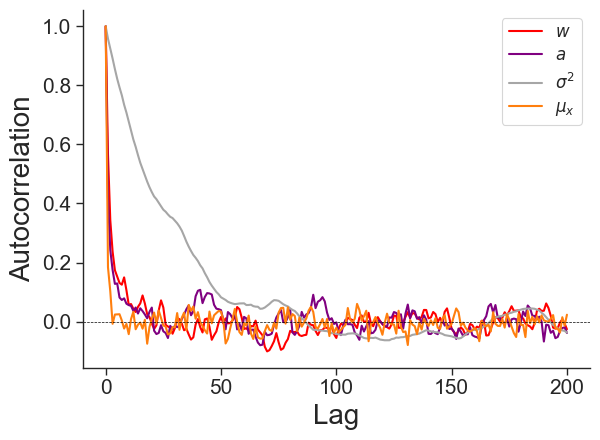

In [630]:
n_lag = 200
dataset = 7
subject_id = 7

acf_w = sm.tsa.acf(all_posterior_samples_w[dataset][burn_in:, subject_id, 0], nlags=n_lag)
acf_a = sm.tsa.acf(all_posterior_samples_a[dataset][burn_in:, subject_id], nlags=n_lag)
acf_sigmasq = sm.tsa.acf(all_posterior_samples_sigmasq[dataset][burn_in:, subject_id], nlags=n_lag)
acf_mu_x = sm.tsa.acf(all_posterior_samples_mu_x[dataset][burn_in:, subject_id], nlags=n_lag)

plt.plot(acf_w, label=r"$w$", color='red')
plt.plot(acf_a, label=r"$a$", color='purple')
plt.plot(acf_sigmasq, label=r"$\sigma^2$", color='#A6A6A6')
plt.plot(acf_mu_x, label=r"$\mu_x$", color='#FF7F0E')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.savefig("acf_per_subject_params.png", transparent=True, bbox_inches='tight', dpi=600)

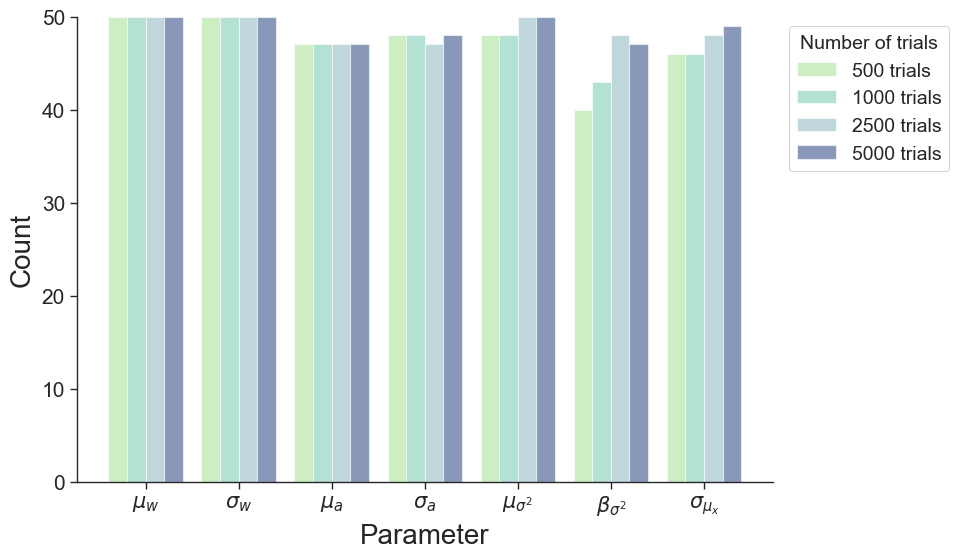

In [669]:
conditions = [r'$\mu_w$', '$\sigma_w$', '$\mu_a$', '$\sigma_a$', '$\mu_{\sigma^2}$', r'$\beta_{\sigma^2}$', r'$\sigma_{\mu_x}$']
trials = [500, 1000, 2500, 5000]
counts = [
    [50, 50, 50, 50],
    [50, 50, 50, 50],
    [47, 47, 47, 47], 
    [48, 48, 47, 48],
    [48, 48, 50, 50],
    [40, 43, 48, 47],
    [46, 46, 48, 49],
]

counts = np.array(counts) 

x = np.arange(len(conditions))  # base x locations for each condition
bar_width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#ADE19C','#81CDB6','#94BBC6','#3b528b']

for i in range(len(trials)):
    ax.bar(x + i * bar_width, counts[:, i], width=bar_width, 
           label=f'{trials[i]} trials', color=colors[i], alpha=0.6)
    
ax.set_ylabel('Count')
ax.set_xlabel('Parameter')
ax.set_xticks(x + bar_width * 1.5)  # center the ticks
ax.set_xticklabels(conditions)
ax.set_ylim(0, 50)
ax.legend(title='Number of trials',bbox_to_anchor=(1.01, 1), loc='upper left', title_fontsize=14, fontsize=14)
plt.tight_layout()
plt.savefig("counts_95CI_trials.png", transparent=True, bbox_inches='tight', dpi=600)


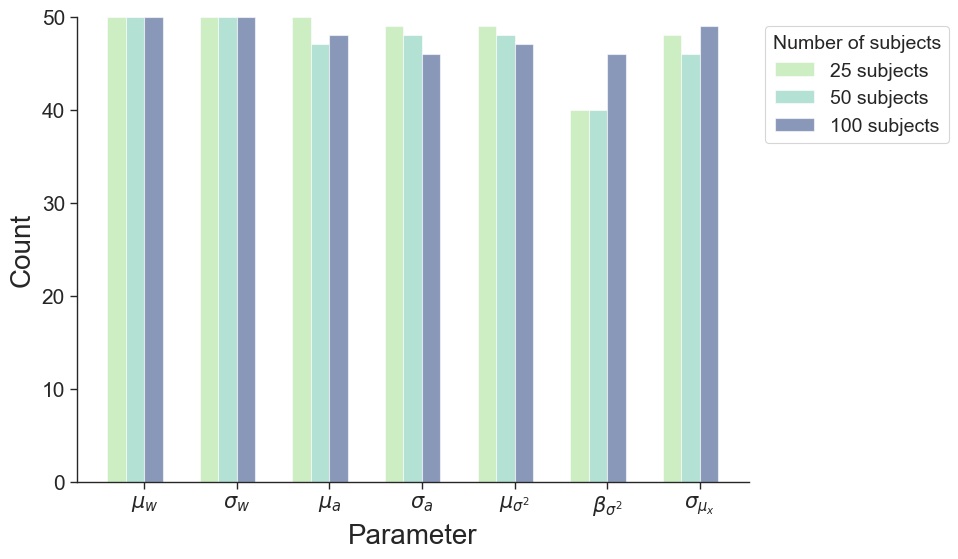

In [670]:
conditions = [r'$\mu_w$', '$\sigma_w$', '$\mu_a$', '$\sigma_a$', '$\mu_{\sigma^2}$', r'$\beta_{\sigma^2}$', r'$\sigma_{\mu_x}$']
subjects = [25, 50, 100]
counts = [
    [50, 50, 50],
    [50, 50, 50],
    [50, 47, 48], 
    [49, 48, 46],
    [49, 48, 47],
    [40, 40, 46],
    [48, 46, 49],
]

counts = np.array(counts) 

x = np.arange(len(conditions))  # base x locations for each condition
bar_width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#ADE19C','#81CDB6','#3b528b']

for i in range(len(subjects)):
    ax.bar(x + i * bar_width, counts[:, i], width=bar_width, 
           label=f'{subjects[i]} subjects', color=colors[i], alpha=0.6)
    
ax.set_ylabel('Count')
ax.set_xlabel('Parameter')
ax.set_xticks(x + bar_width * 1.5)  # center the ticks
ax.set_xticklabels(conditions)
ax.set_ylim(0, 50)
ax.legend(title='Number of subjects',bbox_to_anchor=(1.01, 1), loc='upper left', title_fontsize=14, fontsize=14)
plt.tight_layout()
plt.savefig("counts_95CI_subjects.png", transparent=True, bbox_inches='tight', dpi=600)

In [543]:
"""
Check log joint probability to assess convergence and determine number of burn-in iterations
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_log_joint_prob.pdf') as pdf:
  for dataset in range(num_datasets):
      
      plt.figure(figsize=(8, 6), dpi=600)
      plt.plot(jnp.stack(all_lps[dataset])/(num_trials*num_subjects)) # normalized log joint prob
      plt.title(r"Dataset {:d}".format(dataset))
      plt.xlabel("Iteration")
      plt.ylabel("Log joint probability")

      pdf.savefig()
      plt.close()

In [544]:
"""
Estimated criterion fluctuations for one example dataset
"""

# Select a dataset
dataset = 0

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_estimated_states_one_dataset.pdf') as pdf:
  for subject in range(num_subjects):
      
      plt.figure(figsize=(8, 6), dpi=600)
      plt.plot(all_true_states[dataset][subject], label="True states", linewidth=2, color='red', alpha=.6)
      plt.plot(all_posterior_samples_states[dataset][subject], label="Inferred states", linewidth=2.5)
      plt.fill_between(jnp.arange(num_trials),
                all_posterior_samples_states[dataset][subject] - 2 * all_posterior_samples_states_sd[dataset][subject],
                all_posterior_samples_states[dataset][subject] + 2 * all_posterior_samples_states_sd[dataset][subject], color='r', alpha=0.25)
      plt.xlabel("Trial")
      plt.ylabel("Criterion $x_t$")
      plt.title(r"Subject {:d}".format(subject))
      plt.legend(loc='lower right')
      r, p = spearmanr(all_true_states[dataset][subject], all_posterior_samples_states[dataset][subject])
      plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')

      pdf.savefig()
      plt.close()

Text(0.05, 0.92, 'r = 0.88')

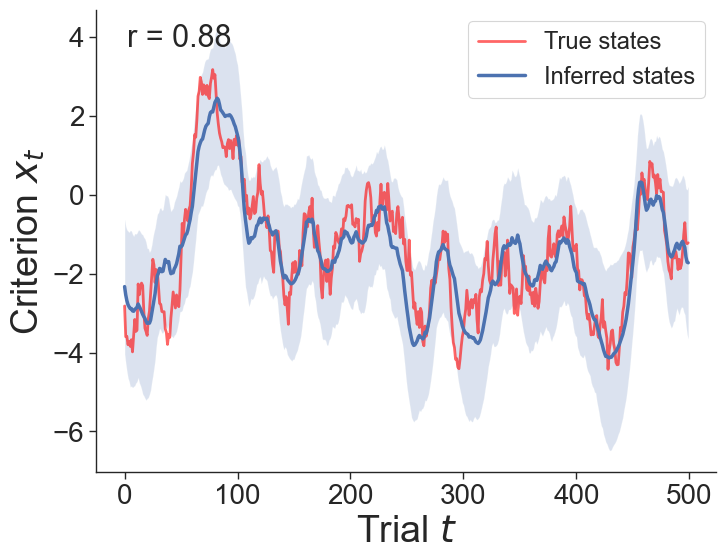

In [545]:
"""
Estimated criterion fluctuations for one example participant
"""

dataset = 0
subject = 2

plt.figure(figsize=(8, 6))
plt.plot(all_true_states[dataset][subject], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(all_posterior_samples_states[dataset][subject], label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(num_trials),
          all_posterior_samples_states[dataset][subject] - 2 * all_posterior_samples_states_sd[dataset][subject],
          all_posterior_samples_states[dataset][subject] + 2 * all_posterior_samples_states_sd[dataset][subject], alpha=0.2)
plt.xlabel("Trial $t$", fontsize=27)
plt.ylabel("Criterion $x_t$", fontsize=27)
plt.xticks(size=20)
plt.yticks(size=20)
#plt.ylim(-5.5,5.5)
#plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='upper right', fontsize=17)
r, p = spearmanr(all_true_states[dataset][subject], all_posterior_samples_states[dataset][subject])
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.92), xycoords='axes fraction', fontsize=22)

#plt.savefig("estimated_criterion.png", transparent=True, dpi=600)

In [546]:
"""
Recovery criterion fluctuations all datasets
"""

average_recovery_states_all_datasets = []
median_recovery_states_all_datasets = []

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_recovery_states.pdf') as pdf:
  for dataset in range(num_datasets):

    correlations_inferred_and_fitted_states = []
    
    for subject in range(num_subjects):
        r, _= spearmanr(all_true_states[dataset][subject], all_posterior_samples_states[dataset][subject])
        correlations_inferred_and_fitted_states.append(r)
    
    correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)
    
    mean_value = jnp.mean(correlations_inferred_and_fitted_states)
    median_value = jnp.median(correlations_inferred_and_fitted_states)
    
    average_recovery_states_all_datasets.append(mean_value)
    median_recovery_states_all_datasets.append(median_value)
    
    plt.figure(figsize=(8, 6), dpi=600)
    sns.histplot(data=correlations_inferred_and_fitted_states, bins=25)
    plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=18)
    plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=18)
    plt.xlabel('Spearman correlation generative and fitted criterion', fontsize=18)
    plt.ylabel('Count', fontsize=18)
    plt.title(r"Dataset {:d}".format(dataset))
    plt.xlim(0,1)
    
    pdf.savefig()
    plt.close()

(0.0, 1.0)

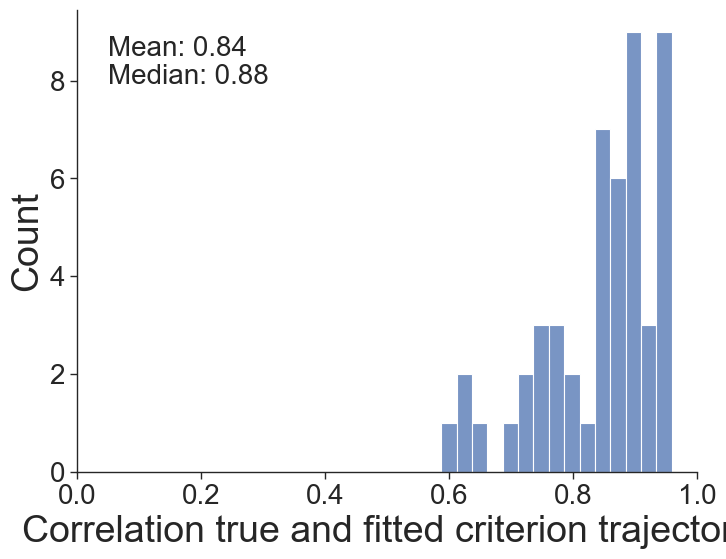

In [547]:
"""
Recovery criterion fluctuations one example dataset
"""

dataset = 14


correlations_inferred_and_fitted_states = []

for subject in range(num_subjects):
    r, _= spearmanr(all_true_states[dataset][subject], all_posterior_samples_states[dataset][subject])
    correlations_inferred_and_fitted_states.append(r)

correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

average_recovery_states_all_datasets.append(mean_value)
median_recovery_states_all_datasets.append(median_value)

plt.figure(figsize=(8, 6))
sns.histplot(data=correlations_inferred_and_fitted_states, bins=15)

#plt.title("Correlation between inferred and fitted states over subjects")
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=20)
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.84), xycoords='axes fraction', fontsize=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel('Correlation true and fitted criterion trajectory', fontsize=27)
plt.ylabel('Count', fontsize=27)
#plt.title(r"Dataset {:d}".format(dataset))
plt.xlim(0,1)
#plt.savefig("recovery_criterion.png", transparent=True, dpi=600)

In [107]:
"""
Compare true and inferred estimates of a_i averaged over iterations (minus the burn-in) for all datasets
"""


with PdfPages(f'{num_subjects}subjects_{num_trials}trials_recovery_a.pdf') as pdf:
  for dataset in range(num_datasets):
    
    a_min = min(all_true_params[dataset]['a'].min(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).min())
    a_max = max(all_true_params[dataset]['a'].max(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).max())
    
    plt.figure(figsize=(8, 6), dpi=600)
    plt.scatter(all_true_params[dataset]['a'], jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0))
    plt.plot([a_min, a_max], [a_min, a_max], '-k')
    plt.xlabel("True $a$")
    plt.ylabel("Inferred $a$")
    plt.title(r"Dataset {:d}".format(dataset))
    plt.gca().set_aspect(1.0)
    r, p = spearmanr(all_true_params[dataset]['a'], jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0))
    plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
        
    pdf.savefig()
    plt.close()

Text(0.05, 0.85, 'r = 0.73')

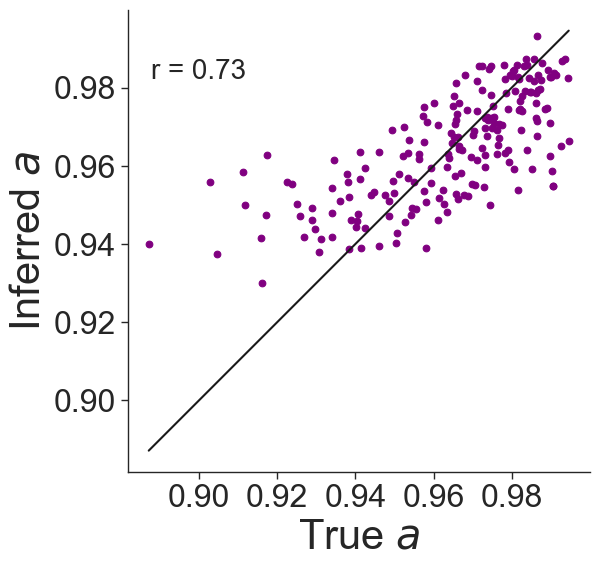

In [108]:
"""
Compare true and inferred estimates of a_i averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 12

a_min = min(all_true_params[dataset]['a'].min(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).min())
a_max = max(all_true_params[dataset]['a'].max(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['a'], jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0), color="purple")
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$", size=30)
plt.ylabel("Inferred $a$",size=30)
plt.xticks(size=23)
plt.yticks(size=23)

#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['a'], jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
#plt.savefig("recovery_a_5000.png", transparent=True, dpi=600)


In [109]:
"""
Compare true and inferred estimates of sigma_sq averaged over iterations (minus the burn-in) for all datasets
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_recovery_sigmasq.pdf') as pdf:
  for dataset in range(num_datasets):
    
    sigmasq_min = min(all_true_params[dataset]['sigmasq'].min(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).min())
    sigmasq_max = max(all_true_params[dataset]['sigmasq'].max(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).max())
    
    plt.figure(figsize=(8, 6), dpi=600)
    plt.scatter(all_true_params[dataset]['sigmasq'], jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0))
    plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
    plt.xlabel("True $\sigma^2$")
    plt.ylabel("Inferred $\sigma^2$")
    plt.title(r"Dataset {:d}".format(dataset))
    plt.gca().set_aspect(1.0)
    r, p = spearmanr(all_true_params[dataset]['sigmasq'], jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0))
    plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
        
    pdf.savefig()
    plt.close()

Text(0.05, 0.85, 'r = 0.62')

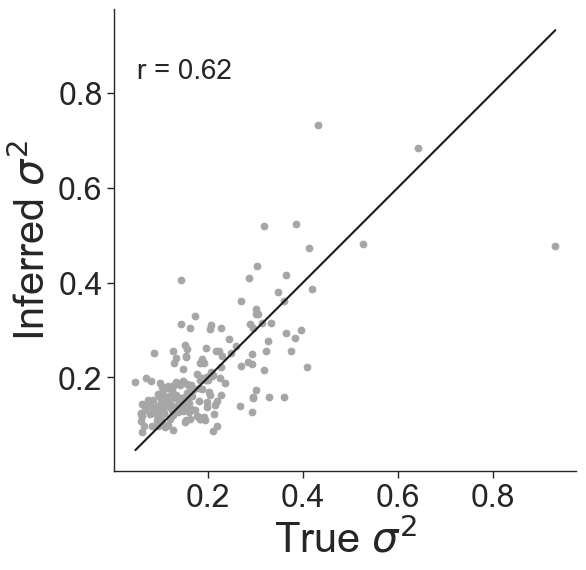

In [110]:
"""
Compare true and inferred estimates of sigma_sq averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 8

sigmasq_min = min(all_true_params[dataset]['sigmasq'].min(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).min())
sigmasq_max = max(all_true_params[dataset]['sigmasq'].max(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['sigmasq'], jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0), color="#A6A6A6")
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $\sigma^2$", size=30)
plt.ylabel("Inferred $\sigma^2$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['sigmasq'], jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
#plt.savefig("recovery_sigmasq_5000.png", transparent=True, dpi=600)


In [111]:
"""
Compare true and inferred estimates of mu_x averaged over iterations (minus the burn-in) for all datasets
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_recovery_mu_x.pdf') as pdf:
  for dataset in range(num_datasets):
    
    mu_x_min = min(all_true_params[dataset]['mu_x'].min(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).min())
    mu_x_max = max(all_true_params[dataset]['mu_x'].max(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).max())
    
    plt.figure(figsize=(8, 6), dpi=600)
    plt.scatter(all_true_params[dataset]['mu_x'], jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0))
    plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
    plt.xlabel("True $\mu_0$")
    plt.ylabel("Inferred $\mu_0$")
    plt.title(r"Dataset {:d}".format(dataset))
    plt.gca().set_aspect(1.0)
    r, p = spearmanr(all_true_params[dataset]['mu_x'], jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0))
    plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
        
    pdf.savefig()
    plt.close()

Text(0.05, 0.85, 'r = 0.67')

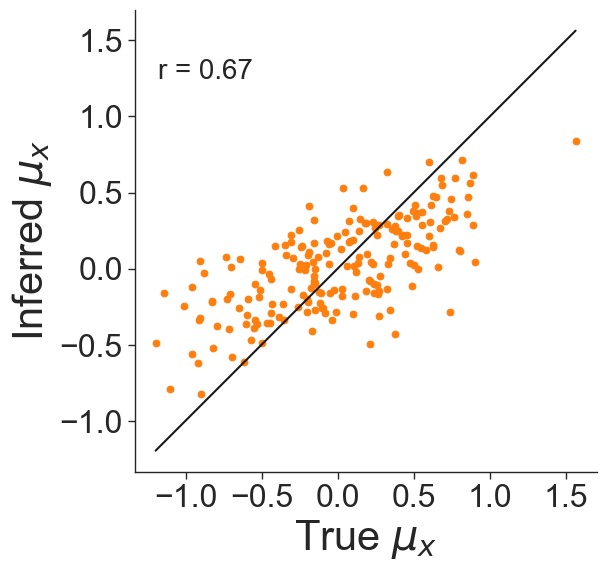

In [112]:
"""
Compare true and inferred estimates of mu_x averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 29

mu_x_min = min(all_true_params[dataset]['mu_x'].min(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).min())
mu_x_max = max(all_true_params[dataset]['mu_x'].max(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['mu_x'], jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0), color="#FF7F0E")
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $\mu_x$", size=30)
plt.ylabel("Inferred $\mu_x$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(all_true_params[dataset]['mu_x'], jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
#plt.savefig("recovery_mu_x_5000.png", transparent=True, dpi=600)

In [113]:
"""
Compare true and inferred estimates of w averaged over iterations (minus the burn-in) for all datasets
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_recovery_w.pdf') as pdf:
  for dataset in range(num_datasets):
      
    w_min = min(all_true_params[dataset]["w"].min(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).min())
    w_max = max(all_true_params[dataset]["w"].max(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).max())
    
    fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
    fig.suptitle(r"Dataset {:d}".format(dataset), size=20)
    fig.subplots_adjust(top=1.3)
    for d, ax in enumerate(axs):
        ax.scatter(all_true_params[dataset]["w"][:, d], jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,d], axis=0))
        ax.set_xlabel(r"True $w_{:d}$".format(d), size=20)
        ax.set_ylabel(r"Inferred $w_{:d}$".format(d), size=20)
        ax.plot([w_min, w_max], [w_min, w_max], '-k')
        ax.set_aspect(1.0)
        r, p = spearmanr(all_true_params[dataset]["w"][:, d], jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,d], axis=0))
        ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=18)
        
    pdf.savefig()
    plt.close()

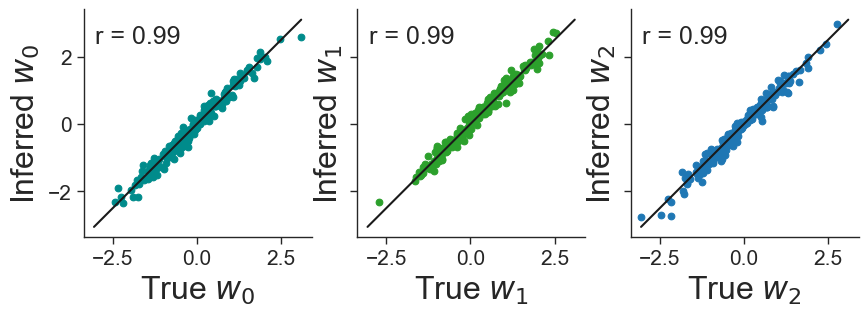

In [114]:
"""
Compare true and inferred estimates of w averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 0
colors = ['darkcyan', '#2ca02c', '#1f77b4', '#ff7f0e']
w_min = min(all_true_params[dataset]["w"].min(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).min())
w_max = max(all_true_params[dataset]["w"].max(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5))
#fig.suptitle(r"Dataset {:d}".format(dataset))
fig.subplots_adjust(top=1.3)

for d, ax in enumerate(axs):
    ax.scatter(all_true_params[dataset]["w"][:, d], jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,d], axis=0), color= colors[d])
    ax.set_xlabel(r"True $w_{:d}$".format(d), size=23)
    ax.set_ylabel(r"Inferred $w_{:d}$".format(d), size=23)
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    ax.set_aspect(1.0)
    r, p = spearmanr(all_true_params[dataset]["w"][:, d], jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=18)

plt.savefig("recovery_w_5000.png", transparent=True, dpi=600)

In [115]:
# ================================================================== #
# GLOBAL (HIERARCHICAL) PARAMETERS
# ================================================================== #

"""
Posterior distributions of mu_w (mean of normal distribution for w_i)
"""



with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_w.pdf') as pdf:
    for dataset in range(num_datasets):
        fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
        fig.suptitle("Posterior distributions", fontsize=16)
        fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)
        
        mean_true_per_subject_w = jnp.mean(all_true_params[dataset]['w'], axis=0)
        for d, ax in enumerate(axs):
            ax.hist(all_posterior_samples_mu_w[dataset][burn_in:, d], bins=30)
            ax.axvline(x=true_mu_w[d], color='black', linewidth=3)
            ax.axvline(x=mean_true_per_subject_w[d], color='red', linewidth=3)
            
            if d == 0:
                ax.set_ylabel("Count", fontsize=15)
            ax.set_xlabel(r"$w_{:d}$".format(d), fontsize=15)
            
        fig.legend([r"True $w$", r'Mean true per-subject $w_i$'])
        
        pdf.savefig()
        plt.close()
        

In [116]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_w_over_iterations.pdf') as pdf:
    for dataset in range(num_datasets):
        fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
        fig.suptitle("Posterior distributions", fontsize=16)
        fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)
        
        mean_true_per_subject_w = jnp.mean(all_true_params[dataset]['w'], axis=0)
        for d, ax in enumerate(axs):
            ax.plot(all_posterior_samples_mu_w[dataset][burn_in:, d])
            ax.axhline(y=true_mu_w[d], color='black')
            ax.axhline(y=mean_true_per_subject_w[d], color='red')
            ax.set_xlabel("Iteration", fontsize=15)
            ax.set_ylabel(r"$w_{:d}$".format(d), fontsize=15)
            
        fig.legend([Line2D([0], [0], color='black'), Line2D([0], [0], color='red')],[r"True $w$", r'Mean true per-subject $w_i$']) # fix to have black line in legend (without it is blue)

        pdf.savefig()
        plt.close()

In [117]:
"""
Posterior distributions of sigma_w (variance of normal distribution for w_i)
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_w.pdf') as pdf:
    for dataset in range(num_datasets):
        fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
        fig.suptitle("Posterior distributions", fontsize=16)
        fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)
        
        sd_true_per_subject_w = jnp.std(all_true_params[dataset]['w'], axis=0)
        for d, ax in enumerate(axs):
            ax.hist(all_posterior_samples_sigma_w[dataset][burn_in:, d], bins=30)
            ax.axvline(x=true_sigma_w[d], color='black')
            ax.axvline(x=sd_true_per_subject_w[d], color='red')
            if d == 0:
                ax.set_ylabel("Count", fontsize=15)
            ax.set_xlabel(r"$\sigma_{{w_{:d}}}$".format(d), fontsize=15)

        fig.legend([r"True $\sigma_w$", r'Sd true per-subject $w_i$'])
        
        pdf.savefig()
        plt.close()

In [118]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_w_over_iterations.pdf') as pdf:
    for dataset in range(num_datasets):
        fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
        fig.suptitle("Posterior distributions", fontsize=16)
        fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)
        
        sd_true_per_subject_w = jnp.std(all_true_params[dataset]['w'], axis=0)
        for d, ax in enumerate(axs):
            ax.plot(all_posterior_samples_sigma_w[dataset][burn_in:, d])
            ax.axhline(y=true_sigma_w[d], color='black')
            ax.axhline(y=sd_true_per_subject_w[d], color='red')
            ax.set_xlabel("Iteration", fontsize=15)
            ax.set_ylabel(r"$\sigma_{{w_{:d}}}$".format(d), fontsize=15)

        fig.legend([Line2D([0], [0], color='black'), Line2D([0], [0], color='red')],[r"True $\sigma_w$", r'Mean true per-subject $w_i$']) # fix to have black line in legend (without it is blue)

        pdf.savefig()
        plt.close()

In [119]:
"""
Posterior distributions of mu_a (mean of truncated normal for a_i)
"""


with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_a.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.hist(all_posterior_samples_mu_a[dataset][burn_in:], bins=30)
    plt.axvline(true_mu_a, color='black', label="True $\mu_a$")
    plt.axvline(jnp.mean(all_true_params[dataset]['a']), color='red', label="Mean true per-subject $a_i$")
    plt.xlabel("$\mu_a$")
    plt.ylabel("Count")
    plt.legend(loc='upper right')
    plt.suptitle("Posterior distributions", fontsize=16)
    plt.title("Dataset {:d}".format(dataset), fontsize=12)

    pdf.savefig()
    plt.close()
    

In [120]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_a_over_iterations.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(all_posterior_samples_mu_a[dataset][burn_in:])
    plt.axhline(true_mu_a, color='black', label="True $\mu_a$")
    plt.axhline(jnp.mean(all_true_params[dataset]['a']), color='red', label="Mean true per-subject $a_i$")
    plt.xlabel("Iteration")
    plt.ylabel("$\mu_a$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [121]:
"""
Posterior distributions of sigma_a (standard deviation of truncated normal for a_i)
"""


with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_a.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.hist(all_posterior_samples_sigma_a[dataset][burn_in:], bins=30)
    plt.axvline(true_sigma_a, color='black', label=r"True $\sigma_a$")
    plt.axvline(jnp.std(all_true_params[dataset]['a']), color='red', label="Std true per-subject $a_i$")
    plt.ylabel("Count")
    plt.xlabel(r"$\sigma_a$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [122]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_a_over_iterations.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(all_posterior_samples_sigma_a[dataset][burn_in:])
    plt.axhline(true_sigma_a, color='black', label=r"True $\sigma_a$")
    plt.axhline(jnp.std(all_true_params[dataset]['a']), color='red', label="Std true per-subject $a_i$")
    plt.xlabel("Iteration")
    plt.ylabel(r"$\sigma_a$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [123]:
"""
Posterior distributions of sigma_mu_x (standard deviation of normal distribution for mu_x) 
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_mu_x.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.hist(all_posterior_samples_sigma_mu_x[dataset][burn_in:], bins=30)
    plt.axvline(true_sigma_mu_x, color='black', label=r"True $\sigma_{\mu_{x}}$")
    plt.ylabel("Count")
    plt.xlabel(r"$\sigma_{\mu_{x}}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [124]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_sigma_mu_x_over_iterations.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(all_posterior_samples_sigma_mu_x[dataset][burn_in:])
    plt.axhline(true_sigma_mu_x, color='black', label=r"True $\sigma_{\mu_{x}}$")
    plt.xlabel("Iteration")
    plt.ylabel(r"$\sigma_{\mu_{x}}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [125]:
"""
Posterior distributions of mu_sigmasq (shape parameter of inverse gamma for sigmasq)
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_sigmasq.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.hist(all_posterior_samples_mu_sigmasq[dataset][burn_in:], bins=30)
    plt.axvline(true_mu_sigmasq, color='black', label=r"True $\mu_{\sigma^2}$")
    plt.ylabel("Count")
    plt.xlabel(r"$\mu_{\sigma^2}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [126]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_mu_sigmasq_over_iterations.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(all_posterior_samples_mu_sigmasq[dataset][burn_in:])
    plt.axhline(true_mu_sigmasq, color='black', label=r"True $\mu_{\sigma^2}$")
    plt.xlabel("Iteration")
    plt.ylabel(r"$\mu_{\sigma^2}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [127]:
"""
Posterior distributions of beta_sigmasq (scale parameter of inverse gamma for sigmasq)
"""

with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_beta_sigmasq.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.hist(all_posterior_samples_beta_sigmasq[dataset][burn_in:], bins=30)
    plt.axvline(true_beta_sigmasq, color='black', label=r"True $\beta_{\sigma^2}$")
    plt.ylabel("Count")
    plt.xlabel(r"$\beta_{\sigma^2}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()
    
    

In [128]:
# Same as above but now shown over time
with PdfPages(f'{num_subjects}subjects_{num_trials}trials_posterior_beta_sigmasq_over_iterations.pdf') as pdf:
  for dataset in range(num_datasets):
      
    plt.figure(figsize=(8, 6), dpi=600)
    plt.plot(all_posterior_samples_beta_sigmasq[dataset][burn_in:])
    plt.axhline(true_beta_sigmasq, color='black', label=r"True $\beta_{\sigma^2}$")
    plt.xlabel("Iteration")
    plt.ylabel(r"$\beta_{\sigma^2}$")
    plt.legend(loc='upper right')
    plt.title(r"Dataset {:d}".format(dataset))
        
    pdf.savefig()
    plt.close()

In [129]:
"""
Check for how many datasets the TRUE global (hierarchical) parameter value is within the 95% credible interval
"""

def within_95_ci(posterior_samples,
                 true_param,
                 w_true=False,
                 variable_index=0): # indicate which w
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        if w_true: # to bypass different data formatting for mu_w and sigma_w
            posterior = posterior_samples[dataset][burn_in:,variable_index]
            
        if jnp.percentile(posterior, 2.5) < true_param < jnp.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



In [132]:
mu_sigmasq = within_95_ci(all_posterior_samples_mu_sigmasq, true_mu_sigmasq)
print("mu_sigmasq", mu_sigmasq, "/", num_datasets)

beta_sigmasq = within_95_ci(all_posterior_samples_beta_sigmasq, true_beta_sigmasq)
print("beta_sigmasq:", beta_sigmasq, "/", num_datasets)

mu_a = within_95_ci(all_posterior_samples_mu_a, true_mu_a)
print("mu_a:", mu_a, "/", num_datasets)

sigma_a = within_95_ci(all_posterior_samples_sigma_a, true_sigma_a)
print("sigma_a:", sigma_a, "/", num_datasets)

sigma_mu_x = within_95_ci(all_posterior_samples_sigma_mu_x, true_sigma_mu_x)
print("sigma_mu_x:", sigma_mu_x, "/", num_datasets)

w0 = within_95_ci(all_posterior_samples_mu_w, true_mu_w[0], w_true=True, variable_index=0)
print("w0:", w0, "/", num_datasets)

w1 = within_95_ci(all_posterior_samples_mu_w, true_mu_w[1], w_true=True, variable_index=1)
print("w1:", w1, "/", num_datasets)

w2 = within_95_ci(all_posterior_samples_mu_w, true_mu_w[2], w_true=True, variable_index=2)
print("w2:", w2, "/", num_datasets)

sigma_w0 = within_95_ci(all_posterior_samples_sigma_w, true_sigma_w[0], w_true=True, variable_index=0)
print("sigma_w0:", sigma_w0, "/", num_datasets)

sigma_w1 = within_95_ci(all_posterior_samples_sigma_w, true_sigma_w[1], w_true=True, variable_index=1)
print("sigma_w1:", sigma_w1, "/", num_datasets)

sigma_w2 = within_95_ci(all_posterior_samples_sigma_w, true_sigma_w[2], w_true=True, variable_index=2)
print("sigma_w2:", sigma_w2, "/", num_datasets)



mu_sigmasq 49 / 50
beta_sigmasq: 49 / 50
mu_a: 44 / 50
sigma_a: 43 / 50
sigma_mu_x: 49 / 50
w0: 44 / 50
w1: 48 / 50
w2: 47 / 50
sigma_w0: 48 / 50
sigma_w1: 49 / 50
sigma_w2: 50 / 50


In [468]:
"""
Check for how many datasets the average per-subject true parameter value is within the 95% credible interval
"""

# Note that we don't do this for alpha and beta (from inverse gamma for sigma_sq) 
# Would require some estimation based on true per-subject sigma_sq to obtain a proxy for alpha and beta
# If needed, use method of moments?

def within_95_ci_subject_w(posterior_samples,
                           variable_index=0,
                           mean=True): # if False then true value is standard deviation of per-subject true w's
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:,variable_index]
        true_value = jnp.std(all_true_params[dataset]['w'][:,variable_index])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['w'][:,variable_index])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



def within_95_ci_subject_a(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['a'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['a'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)



def within_95_ci_subject_mu(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['mu_x'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['mu_x'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)


def within_95_ci_subject_mu_sigmasq(posterior_samples,
                           mean=True): # if False then true value is standard deviation of per-subject true a's
    
    inside_outside = []
    for dataset in range(num_datasets):
        posterior = posterior_samples[dataset][burn_in:]
        true_value = jnp.std(all_true_params[dataset]['sigmasq'])
        if mean:
            true_value = jnp.mean(all_true_params[dataset]['sigmasq'])
                
        if np.percentile(posterior, 2.5) < true_value < np.percentile(posterior, 97.5):
            inside_outside.append(1)
        else:
            inside_outside.append(0)
            
    return sum(inside_outside)

mu_sigmasq_subject = within_95_ci_subject_mu_sigmasq(all_posterior_samples_mu_sigmasq)
print("mu_sigmasq_subject:", mu_sigmasq_subject, "/", num_datasets)
mu_a_subject = within_95_ci_subject_a(all_posterior_samples_mu_a)
print("mu_a_subject:", mu_a_subject, "/", num_datasets)
sigma_a_subject = within_95_ci_subject_a(all_posterior_samples_sigma_a, mean=False)
print("sigma_a_subject:", sigma_a_subject, "/", num_datasets)
sigma_mu_x_subject = within_95_ci_subject_mu(all_posterior_samples_sigma_mu_x, mean=False)
print("sigma_mu_x_subject:", sigma_mu_x_subject, "/", num_datasets)
w0_subject = within_95_ci_subject_w(all_posterior_samples_mu_w, variable_index=0)
print("w0_subject:", w0_subject, "/", num_datasets)
w1_subject = within_95_ci_subject_w(all_posterior_samples_mu_w, variable_index=1)
print("w1_subject:", w1_subject, "/", num_datasets)
w2_subject = within_95_ci_subject_w(all_posterior_samples_mu_w, variable_index=2)
print("w2_subject:", w2_subject, "/", num_datasets)
sigma_w0_subject = within_95_ci_subject_w(all_posterior_samples_sigma_w, variable_index=0, mean=False)
print("sigma_w0_subject:", sigma_w0_subject, "/", num_datasets)
sigma_w1_subject = within_95_ci_subject_w(all_posterior_samples_sigma_w, variable_index=1, mean=False)
print("sigma_w1_subject:", sigma_w1_subject, "/", num_datasets)
sigma_w2_subject = within_95_ci_subject_w(all_posterior_samples_sigma_w, variable_index=2, mean=False)
print("sigma_w2_subject:", sigma_w2_subject, "/", num_datasets)



mu_sigmasq_subject: 34 / 50
mu_a_subject: 29 / 50
sigma_a_subject: 45 / 50
sigma_mu_x_subject: 47 / 50
w0_subject: 50 / 50
w1_subject: 50 / 50
w2_subject: 50 / 50
sigma_w0_subject: 50 / 50
sigma_w1_subject: 50 / 50
sigma_w2_subject: 50 / 50


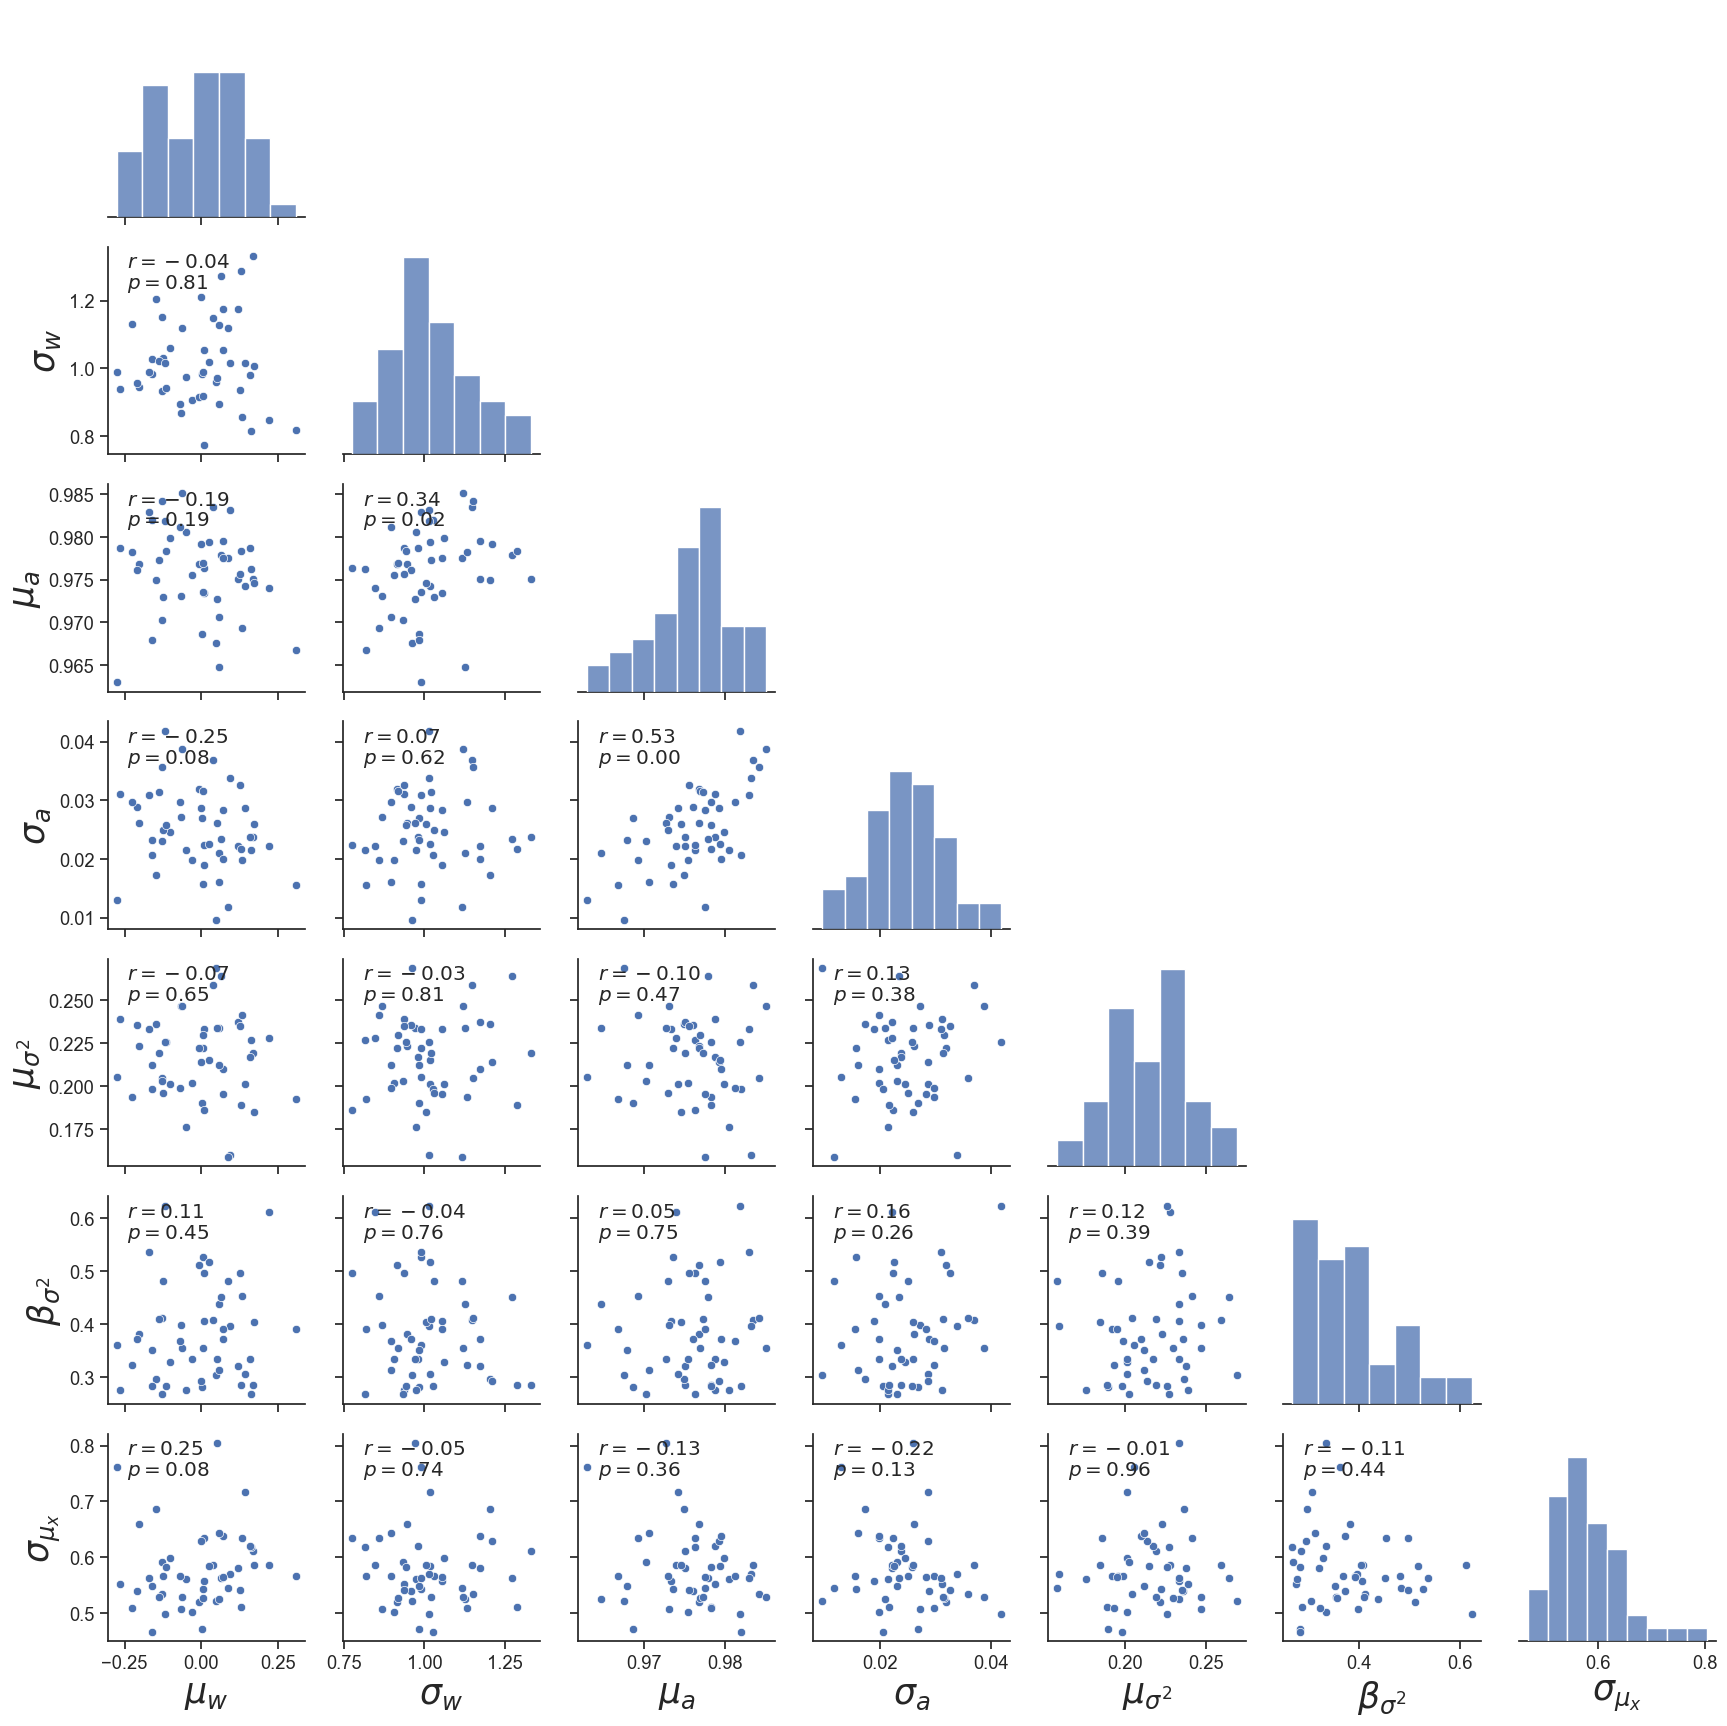

In [678]:
# We don't look at true parameters values here but they are the same over all datasets
all_inf_sigma_mu_x = jnp.stack([jnp.mean(all_posterior_samples_sigma_mu_x[dataset][burn_in:], axis=0) for dataset in range(num_datasets)])
all_inf_mu_sigmasq = jnp.stack([jnp.mean(all_posterior_samples_mu_sigmasq[dataset][burn_in:], axis=0) for dataset in range(num_datasets)])
all_inf_beta_sigmasq = jnp.stack([jnp.mean(all_posterior_samples_beta_sigmasq[dataset][burn_in:], axis=0) for dataset in range(num_datasets)])
all_inf_mu_a = jnp.stack([jnp.mean(all_posterior_samples_mu_a[dataset][burn_in:], axis=0) for dataset in range(num_datasets)])
all_inf_sigma_a = jnp.stack([jnp.mean(all_posterior_samples_sigma_a[dataset][burn_in:], axis=0) for dataset in range(num_datasets)])
all_inf_mu_w = jnp.stack([jnp.mean(all_posterior_samples_mu_w[dataset][burn_in:], axis=0)[0] for dataset in range(num_datasets)])
all_inf_sigma_w = jnp.stack([jnp.mean(all_posterior_samples_sigma_w[dataset][burn_in:], axis=0)[0] for dataset in range(num_datasets)])


df_group_params = pd.DataFrame({
    r"$\mu_w$": all_inf_mu_w,
    r"$\sigma_w$": all_inf_sigma_w,
    r"$\mu_a$": all_inf_mu_a,
    r"$\sigma_a$": all_inf_sigma_a,
    r"$\mu_{\sigma^2}$": all_inf_mu_sigmasq,
    r"$\beta_{\sigma^2}$": all_inf_beta_sigmasq,
    r"$\sigma_{\mu_x}$": all_inf_sigma_mu_x
})

# Define correlation annotation function
def corrfunc(x, y, ax=None, **kws):
    r, p = spearmanr(x, y)
    ax = ax or plt.gca()
    ax.annotate(f'$r = {r:.2f}$', xy=(.1, .9), xycoords=ax.transAxes)
    ax.annotate(f'$p = {p:.2f}$', xy=(.1, .8), xycoords=ax.transAxes)

# Plot with seaborn
sns.set(style="ticks", font_scale=1.2)
g = sns.pairplot(df_group_params, corner=True)
g.map_lower(corrfunc)
for ax in g.axes.flat:
    if ax is not None:
        ax.xaxis.label.set_size(25)  # x-axis label font size
        ax.yaxis.label.set_size(25)  # y-axis label font size
plt.tight_layout()
#plt.savefig("correlation_between_inferred_group_parameters.png", transparent=True, dpi=600)

In [676]:
dataset = 0

df_subject_params = pd.DataFrame({"true mu_x": all_true_params[dataset]['mu_x'],
                                  "true sigmasq": all_true_params[dataset]['sigmasq'],
                                  "true a": all_true_params[dataset]['a'],
                                  "true w": all_true_params[dataset]['w'][:,0], ## problem here?
                                  "inferred mu_x": jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0),
                                  "inferred sigmasq": jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0),
                                  "inferred a": jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0),
                                  "inferred w": jnp.mean(all_posterior_samples_w[dataset][burn_in:], axis=0)[:,0] # or here?
                                  })

#### Inferred and inferred

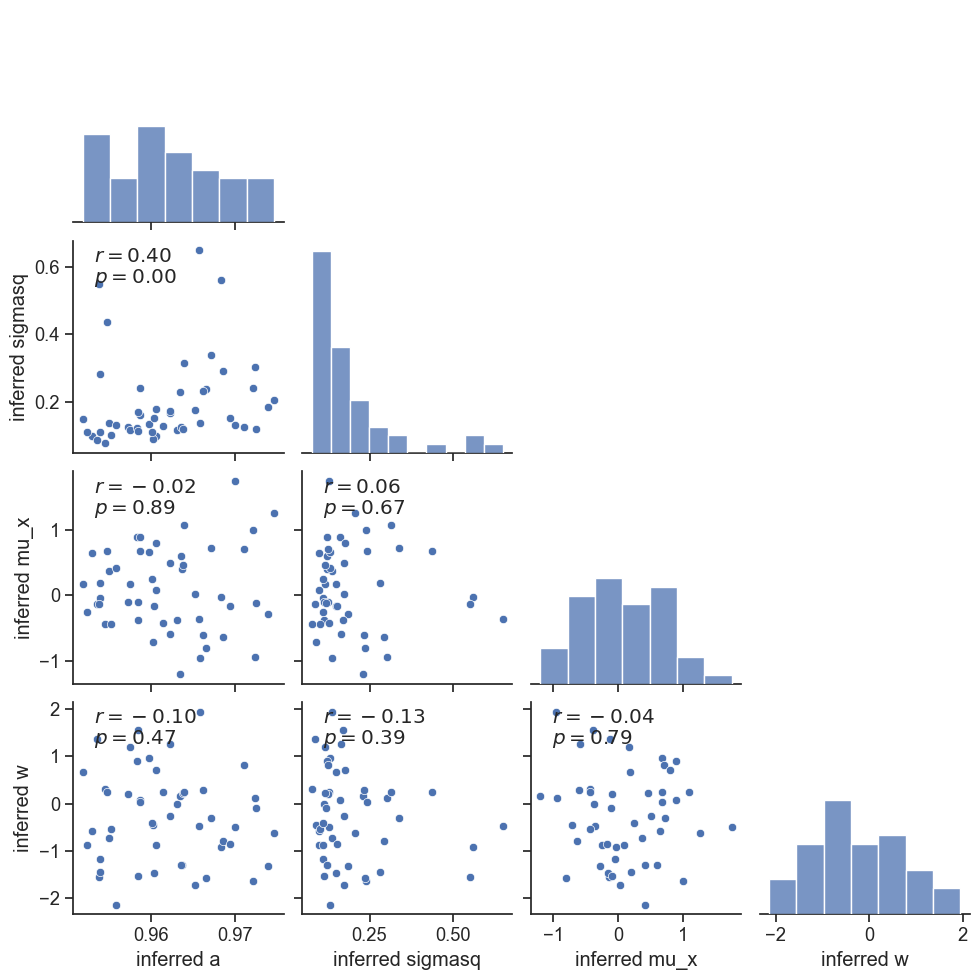

In [140]:
g = sns.pairplot(df_subject_params, 
                 x_vars=("inferred a", "inferred sigmasq", "inferred mu_x", "inferred w"), 
                 y_vars=("inferred a", "inferred sigmasq", "inferred mu_x", "inferred w"), 
                 corner=True)
g.map_lower(corrfunc)
plt.show()

#### True and true

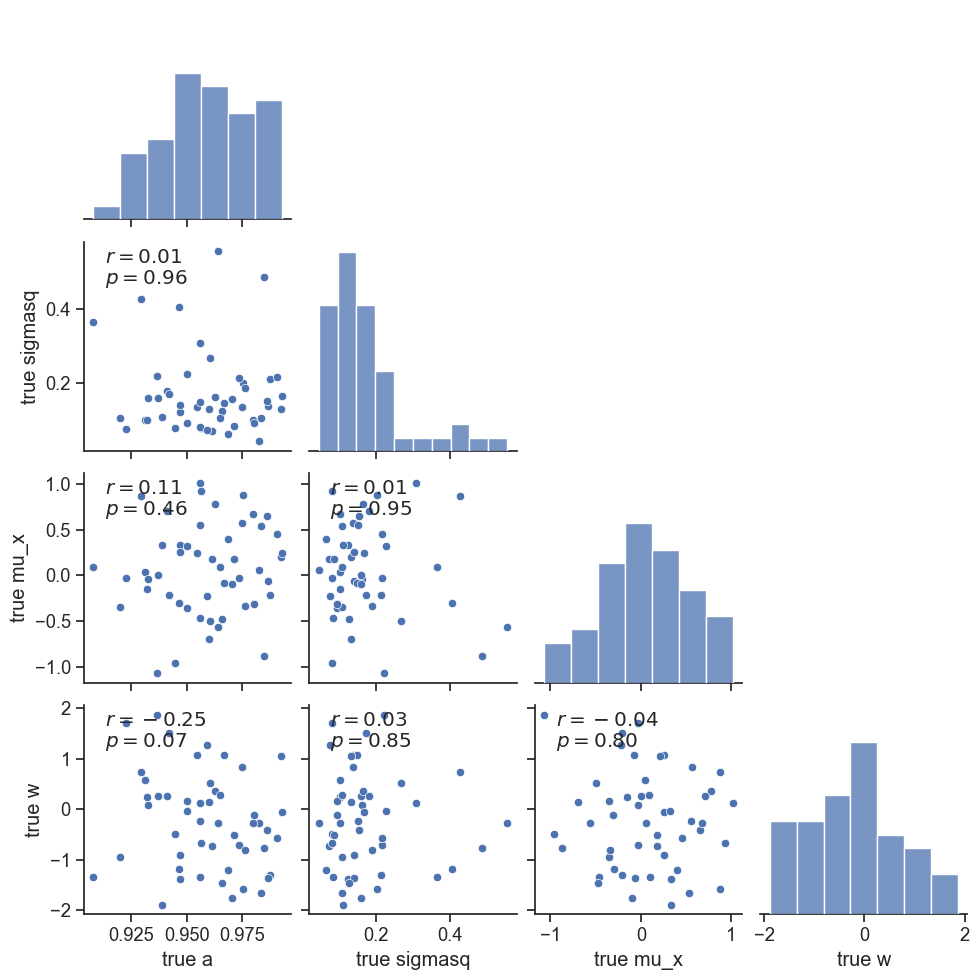

In [141]:
g = sns.pairplot(df_subject_params, 
                 x_vars=("true a", "true sigmasq", "true mu_x", "true w"), 
                 y_vars=("true a","true sigmasq","true mu_x","true w"), 
                 corner=True)
g.map_lower(corrfunc)
plt.show()

#### True and inferred

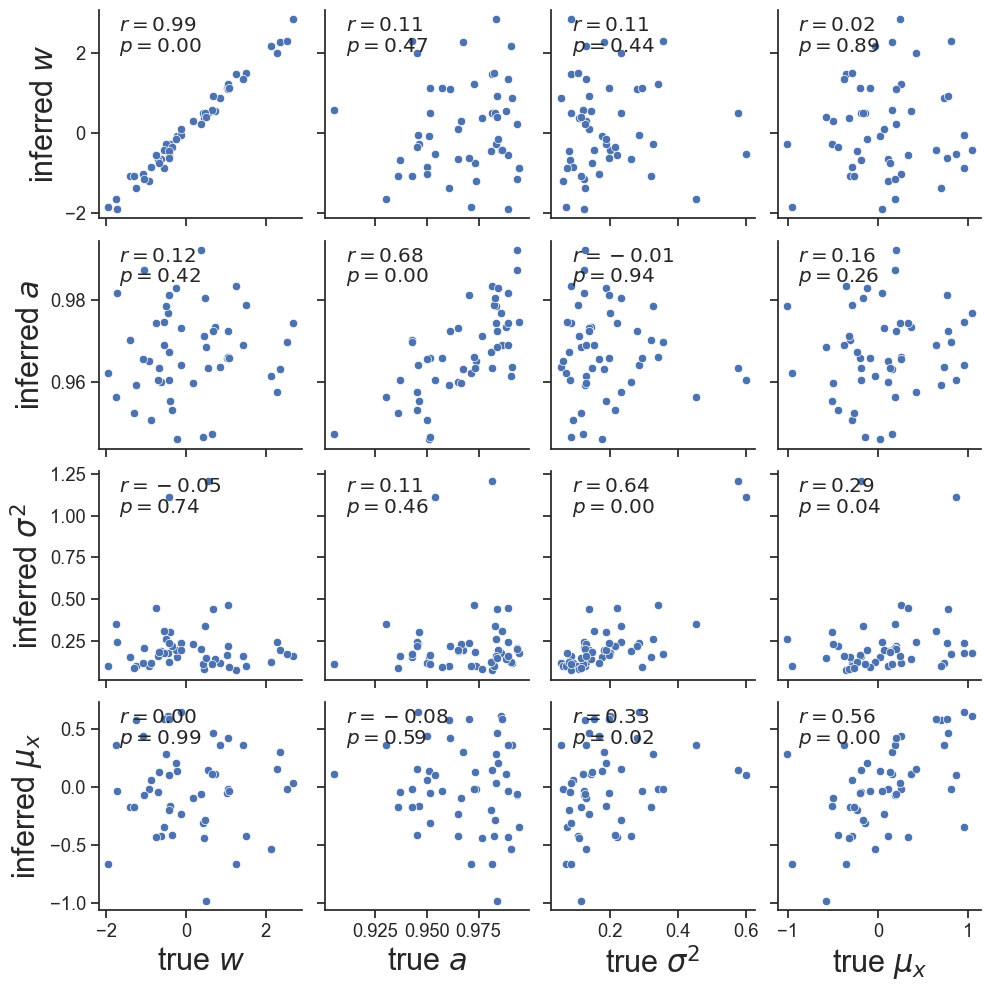

In [691]:
label_map = {
    "true w": r"true $w$",
    "true a": r"true $a$",
    "true sigmasq": r"true $\sigma^2$",
    "true mu_x": r"true $\mu_x$",
    "inferred w": r"inferred $w$",
    "inferred a": r"inferred $a$",
    "inferred sigmasq": r"inferred $\sigma^2$",
    "inferred mu_x": r"inferred $\mu_x$"
    
}

df_labeled = df_subject_params.rename(columns=label_map)

x_vars = [label_map["true w"], label_map["true a"], label_map["true sigmasq"], label_map["true mu_x"]]
y_vars = [label_map["inferred w"], label_map["inferred a"], label_map["inferred sigmasq"], label_map["inferred mu_x"]]

g = sns.pairplot(
    df_labeled,
    x_vars=x_vars,
    y_vars=y_vars,
    corner=False,
    kind="scatter"
)

g.map_lower(corrfunc)
g.map_upper(corrfunc)

for i, (x_var, y_var) in enumerate(zip(x_vars, y_vars)):
    ax = g.axes[i][i]
    x = df_labeled[x_var]
    y = df_labeled[y_var]
    corrfunc(x, y, ax=ax)

for ax_row in g.axes:
    for ax in ax_row:
        if ax is not None:
            ax.xaxis.label.set_size(22)
            ax.yaxis.label.set_size(22)
#plt.savefig("correlation_inferred_true_subject_parameters.png", transparent=True, dpi=600)

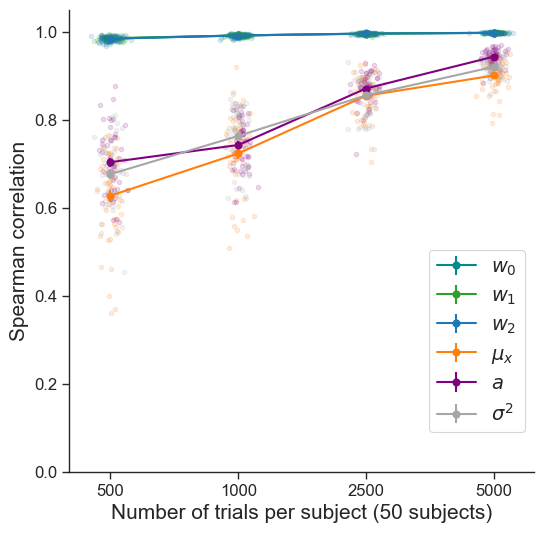

In [534]:
"""
Plotting recovery local parameters
"""


jitter_strength = 0.05
plot_with_each_dataset_as_point = True


# Read in files (burn in trials already removed)
#wd = "C:/Users/u0141056/OneDrive - KU Leuven/PhD/PROJECTS/CHOICE HISTORY BIAS/Correction slow drifts/hLDS/hLDS Gibbs/Parameter recovery/MH for sigmasq/"

data500 = pd.read_csv(wd + '500trials_50subjects_recovery_localparams.csv')
data1000 = pd.read_csv(wd + '1000trials_50subjects_recovery_localparams.csv')
data2500 = pd.read_csv(wd + '2500trials_50subjects_recovery_localparams.csv')
data5000 = pd.read_csv(wd + '5000trials_50subjects_recovery_localparams.csv')


# Define function to read data and calculate means
def process_data(filename):
    data = filename
    means = {
        'w0': np.mean(data["correlation_w0"]),
        'w1': np.mean(data["correlation_w1"]),
        'w2': np.mean(data["correlation_w2"]),
        'mu_x': np.mean(data["correlation_mu_x"]),
        'a': np.mean(data["correlation_a"]),
        'sigmasq': np.mean(data["correlation_sigmasq"]),
        'criterion': np.mean(data["mean_correlation_states"])
    }
    std_errors = {
        'w0': np.std(data["correlation_w0"])/np.sqrt(num_datasets),
        'w1': np.std(data["correlation_w1"])/np.sqrt(num_datasets),
        'w2': np.std(data["correlation_w2"])/np.sqrt(num_datasets),
        'mu_x': np.std(data["correlation_mu_x"])/np.sqrt(num_datasets),
        'a': np.std(data["correlation_a"])/np.sqrt(num_datasets),
        'sigmasq': np.std(data["correlation_sigmasq"])/np.sqrt(num_datasets),
        'criterion': np.std(data["mean_correlation_states"])/np.sqrt(num_datasets)
    }
    return data, means, std_errors


# File names
files = [data500, data1000, data2500, data5000]

# Process data for each file
data = [process_data(file) for file in files]

# Extract values
names = ['500', '1000', '2500', '5000']
individual_data = {key: [data[i][0]["correlation_" + key] for i in range(4)] for key in ['w0', 'w1', 'w2', 'mu_x', 'a', 'sigmasq']}
values = {key: [data[i][1][key] for i in range(4)] for key in ['w0', 'w1', 'w2', 'mu_x', 'a', 'sigmasq']}
std_errors = {key: [data[i][2][key] for i in range(4)] for key in ['w0', 'w1', 'w2', 'mu_x', 'a', 'sigmasq']}

# Define legend labels with symbols
legend_labels = {
    'w0': r"$w_0$",
    'w1': r"$w_1$",
    'w2': r"$w_2$",
    'mu_x': r"$\mu_x$",
    'a': r"$a$",
    'sigmasq': r"$\sigma^2$",
}


plt.figure(figsize=(6, 6))
colors = ['darkcyan', '#2ca02c', '#1f77b4', '#ff7f0e', 'purple', '#A6A6A6']

for i, (key, value) in enumerate(values.items()):
    plt.errorbar(names, value, yerr=std_errors[key], label=legend_labels[key], marker='o', color=colors[i % len(colors)])
    if plot_with_each_dataset_as_point: # Plot individual data points with jitter
        for j in range(len(names)):  # Loop over the 4 data files
            x_jitter = np.random.normal(loc=j, scale=jitter_strength, size=num_datasets)
            plt.scatter(x_jitter, individual_data[key][j], color=colors[i % len(colors)], alpha=0.15, s=10)

plt.xlabel('Number of trials per subject (50 subjects)', size=15)
plt.ylabel('Spearman correlation', size=15)
plt.ylim(0,1.05)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.legend(bbox_to_anchor=(1, .5), fontsize=14)
#plt.savefig("correlation_recovery_local_parameters.png", transparent=True, dpi=600)



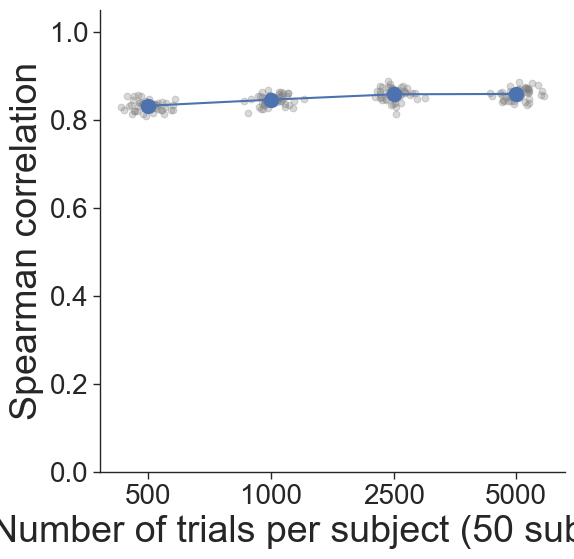

In [27]:

"""
Plotting recovery criterion trajectory
"""


jitter_strength_criterion = 0.1
plot_with_each_dataset_as_point = True # if False then all individual subjects are shown


# Read in extra files (contains recovery correlation of criterion trajectory for each subject, burn in trials already removed)
data500_subjects = pd.read_csv(wd + '500trials_50subjects_recovery_criterion_heatmap.csv')
data1000_subjects = pd.read_csv(wd + '1000trials_50subjects_recovery_criterion_heatmap.csv')
data2500_subjects = pd.read_csv(wd + '2500trials_50subjects_recovery_criterion_heatmap.csv')
data5000_subjects = pd.read_csv(wd + '5000trials_50subjects_recovery_criterion_heatmap.csv')


files = [data500, data1000, data2500, data5000]
files_subjects = [data500_subjects, data1000_subjects, data2500_subjects, data5000_subjects]

# Process data for each file
data = [process_data(file) for file in files]

# Extract values
names = ['500', '1000', '2500', '5000']
values = {key: [data[i][1][key] for i in range(4)] for key in ['criterion']}
std_errors = {key: [data[i][2][key] for i in range(4)] for key in ['criterion']}


plt.figure(figsize=(6, 6))

if plot_with_each_dataset_as_point: # Plot datasets as points
    for i, file in enumerate(files):
        jitter = np.random.normal(0, jitter_strength_criterion, num_datasets)
        plt.scatter(np.array([i + 1] * num_datasets) + jitter, file["mean_correlation_states"], alpha=0.3, color="gray")
else: # Plot all individuals as points
    for i, file in enumerate(files_subjects):
        jitter = np.random.normal(0, jitter_strength_criterion, num_datasets*50)
        plt.scatter(np.array([i + 1] * num_datasets * 50) + jitter, file['correlation'], alpha=0.1, color="gray")
        
# Plot mean values with error bars
for key, value in values.items():
    plt.errorbar(range(1, len(names) + 1), value, yerr=std_errors[key], marker='o', markersize=10)

plt.xticks(ticks=range(1, len(names) + 1), labels=names, fontsize=20)
plt.xlabel('Number of trials per subject (50 subjects)', size=27)
plt.ylabel('Spearman correlation', size=27)
plt.ylim(0.0, 1.05)
plt.yticks(fontsize=20)
plt.savefig("correlation_recovery_criterion.png", transparent=True, dpi=600)


In [527]:

"""
Plotting heatmap
"""


# Contains recovery correlation of criterion trajectory for each subject
# Each file consists of 50 simulated datasets, each with 50 subjects (burn in trials already removed)
data500_subjects = pd.read_csv(wd + '500trials_50subjects_recovery_criterion_heatmap.csv')
data1000_subjects = pd.read_csv(wd + '1000trials_50subjects_recovery_criterion_heatmap.csv')
data2500_subjects = pd.read_csv(wd + '2500trials_50subjects_recovery_criterion_heatmap.csv')
data5000_subjects = pd.read_csv(wd + '5000trials_50subjects_recovery_criterion_heatmap.csv')

# data500_25subjects = pd.read_csv(wd + '500 trials/25 subjects/500trials_25subjects_recovery_criterion_heatmap.csv')
# data500_100subjects = pd.read_csv(wd + '500 trials/100 subjects/500trials_100subjects_recovery_criterion_heatmap.csv')
# data500_200subjects = pd.read_csv(wd + '500 trials/200 subjects/500trials_200subjects_recovery_criterion_heatmap.csv')

combined_data_basic = pd.concat([data500_subjects, data1000_subjects, data2500_subjects, data5000_subjects], axis=0)
# combined_data_all = pd.concat([data500_subjects, data1000_subjects, data2500_subjects, data5000_subjects, data500_25subjects, data500_100subjects, data500_200subjects], axis=0)


# Choose which dataframe
data = combined_data_basic
#data = combined_data_all


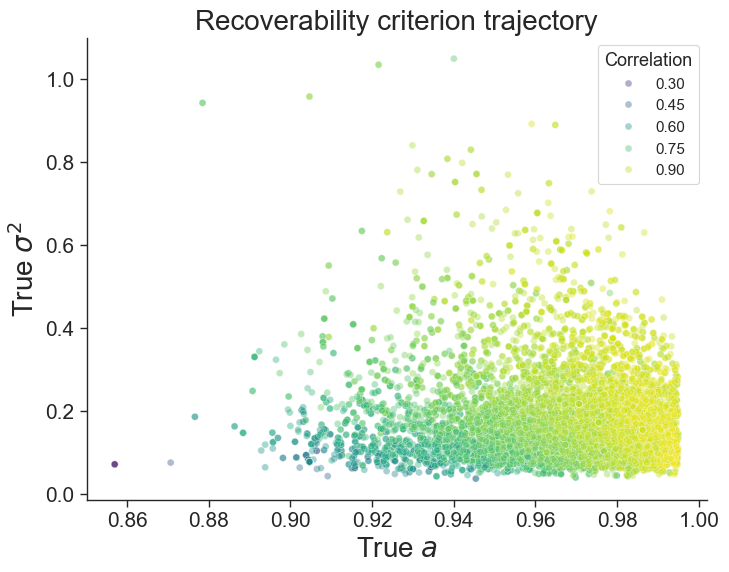

In [533]:
# Plot with generative parameter values
plt.figure(figsize=(8, 6))
sns.scatterplot(x = data["generative_a"], y = data["generative_sigmasq"], hue=data['correlation'], palette='viridis', s=25, alpha=.4)
plt.title('Recoverability criterion trajectory')
plt.xlabel('True $a$')
plt.ylabel(r'True $\sigma^2$')
plt.legend(title='Correlation', title_fontsize='13', fontsize='11')
plt.savefig("criterion_recovery_heatmap.png", transparent=True, dpi=600)

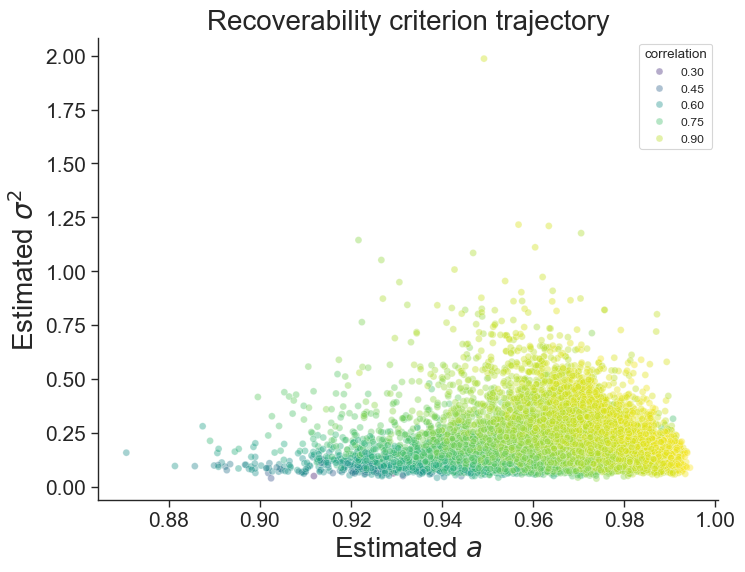

In [530]:
# Plot with estimated parameter values
plt.figure(figsize=(8, 6))
sns.scatterplot(x = data["estimated_a"], y = data["estimated_sigmasq"], hue=data['correlation'], palette='viridis', s=25, alpha=.4)
plt.title('Recoverability criterion trajectory')
plt.xlabel('Estimated $a$')
plt.ylabel('Estimated $\sigma^2$')
plt.show()

In [164]:

"""
Plots for posterior distributions for the group (global) parameters
"""

# Load in the different dill files
# Because variables within these dill files have the same names we have to rename them
num_trials=500

file_25 = file_paths_mapping.get((num_trials, 25))
file_50 = file_paths_mapping.get((num_trials, 50))
file_100 = file_paths_mapping.get((num_trials, 100))
file_200 = file_paths_mapping.get((num_trials, 200))

load_dill_file(file_25[0])

posterior_samples_mu_sigmasq_25 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_25 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_25 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_25 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_25 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_25 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_25 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]

load_dill_file(file_50[0])

posterior_samples_mu_sigmasq_50 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_50 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_50 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_50 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_50 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_50 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_50 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]

load_dill_file(file_100[0])

posterior_samples_mu_sigmasq_100 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_100 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_100 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_100 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_100 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_100 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_100 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]


load_dill_file(file_200[0])

posterior_samples_mu_sigmasq_200 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_200 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_200 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_200 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_200 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_200 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_200 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]




In [173]:
# Contains the posterior means and 95% CI for each dataset (calculated without the burn in trials)
data500_posterior_mean = pd.read_csv(wd + '500trials_50subjects_posterior_means.csv')
data1000_posterior_mean = pd.read_csv(wd + '1000trials_50subjects_posterior_means.csv')
data2500_posterior_mean = pd.read_csv(wd + '2500trials_50subjects_posterior_means.csv')
data5000_posterior_mean = pd.read_csv(wd + '5000trials_50subjects_posterior_means.csv')

data500_25subj_posterior_mean = pd.read_csv(wd + '500trials_25subjects_posterior_means.csv')
data500_50subj_posterior_mean = pd.read_csv(wd + '500trials_50subjects_posterior_means.csv')
data500_100subj_posterior_mean = pd.read_csv(wd + '500trials_100subjects_posterior_means.csv')
data500_200subj_posterior_mean = pd.read_csv(wd + '500trials_200subjects_posterior_means.csv')


all_posterior_means = pd.concat([data500_posterior_mean, data1000_posterior_mean, data2500_posterior_mean, data5000_posterior_mean], axis=0)
all_posterior_means_subj = pd.concat([data500_25subj_posterior_mean, data500_50subj_posterior_mean, data500_100subj_posterior_mean, data500_200subj_posterior_mean], axis=0)


df_posterior_mean_subj = pd.concat([data500_25subj_posterior_mean, data500_posterior_mean, data500_100subj_posterior_mean], axis=0)
df_posterior_mean_subj['dataset'] = np.arange(0,num_datasets).tolist() * 3 # 3 levels of number of subjects



posterior_mu_a = jnp.array([posterior_samples_mu_a_25,posterior_samples_mu_a_50,posterior_samples_mu_a_100]).flatten()
posterior_sigma_a = jnp.array([posterior_samples_sigma_a_25,posterior_samples_sigma_a_50,posterior_samples_sigma_a_100]).flatten()
posterior_mu_sigmasq = jnp.array([posterior_samples_mu_sigmasq_25,posterior_samples_mu_sigmasq_50,posterior_samples_mu_sigmasq_100]).flatten()
posterior_beta_sigmasq = jnp.array([posterior_samples_beta_sigmasq_25,posterior_samples_beta_sigmasq_50,posterior_samples_beta_sigmasq_100]).flatten()
posterior_sigma_mu_x = jnp.array([posterior_samples_sigma_mu_x_25,posterior_samples_sigma_mu_x_50,posterior_samples_sigma_mu_x_100]).flatten()
posterior_mu_w = jnp.array([jnp.stack(posterior_samples_mu_w_25)[:,:,0], jnp.stack(posterior_samples_mu_w_50)[:,:,0], jnp.stack(posterior_samples_mu_w_100)[:,:,0]]).flatten()
posterior_sigma_w = jnp.array([jnp.stack(posterior_samples_sigma_w_25)[:,:,0], jnp.stack(posterior_samples_sigma_w_50)[:,:,0], jnp.stack(posterior_samples_sigma_w_100)[:,:,0]]).flatten()


num_subjects = jnp.repeat(jnp.array([25,50,100]),50*(num_iters-burn_in)) #50 datasets * 1000 iterations
dataset = jnp.tile(jnp.repeat(jnp.arange(0,num_datasets),(num_iters-burn_in), axis=0),3)

df_example_post = pd.DataFrame({
        'mu_a': posterior_mu_a,
        'sigma_a': posterior_sigma_a,
        'mu_sigmasq': posterior_mu_sigmasq,
        'beta_sigmasq': posterior_beta_sigmasq,
        'sigma_mu_x': posterior_sigma_mu_x,
        'mu_w': posterior_mu_w,
        'sigma_w': posterior_sigma_w,
        'num_subjects': num_subjects,
        'dataset': dataset})

df_example_post['num_subjects']= pd.Categorical(df_example_post['num_subjects'], categories=[25, 50, 100])



In [444]:
colors_subject=['#ADE19C','#81CDB6','#3b528b']

# Could use some improvement
def plot_corrected_posteriors(datasets_list, true_params, matched_true_param, matched_dataset, x_label, x_label_top, x_lim_top, x_lim, y_lim, param, filename):

    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(5, 12), sharex=False)
    
    part1 = df_example_post[(df_example_post['num_subjects'] == 25) & (df_example_post['dataset'] == matched_dataset[0])]
    part2 = df_example_post[(df_example_post['num_subjects'] == 50) & (df_example_post['dataset'] == matched_dataset[1])]
    part3 = df_example_post[(df_example_post['num_subjects'] == 100) & (df_example_post['dataset'] == matched_dataset[2])]

    combined = pd.concat([part1, part2, part3], axis=0)
    
    sns.kdeplot(
        data=combined, 
        x=param, 
        hue='num_subjects', 
        palette=colors_subject,
        hue_order=[25, 50, 100], 
        ax=axs[0],  # Moved to the top
        bw_adjust=2, fill=True, alpha=0.7, linewidth=0
    )
    axs[0].axvline(x=matched_true_param, color='red', linestyle='--')
    axs[0].set_yticks([])
    axs[0].set_xlim(x_lim_top)
    axs[0].yaxis.set_tick_params(size=0)
    axs[0].xaxis.set_tick_params(size=5, labelsize=25)
    axs[0].set_xlabel(x_label_top, size=40)
    axs[0].set_ylabel("Density", size=40)
    
    # Loop through other datasets and corresponding axes
    # Stack datasets
    datasets = jnp.stack([jnp.stack(df) for df in datasets_list])
    
    # Subtract true parameters
    corrected_datasets = datasets - true_params
    
    for i, dataset in enumerate(corrected_datasets):
        # Plot the dataset for specific posterior
        for posterior in dataset:
            sns.kdeplot(
                posterior, bw_adjust=2, ax=axs[i + 1],  # Shift by 1 for the remaining axes
                fill=True, color=colors_subject[i], alpha=0.15, linewidth=0
            )
        axs[i + 1].set_ylabel("Density", size=40)  # Shifted to axs[i + 1]
        axs[i + 1].set_xlim(x_lim)
        axs[i + 1].set_ylim(y_lim)
        axs[i + 1].set_yticks([])
        axs[i + 1].yaxis.set_tick_params(size=0)
        axs[i + 1].xaxis.set_tick_params(size=0, labelsize=25)
    
    axs[-1].set_xlabel(x_label, size=40)
    axs[-1].xaxis.set_tick_params(size=5)
    axs[1].set_xticklabels([]) 
    axs[2].set_xticklabels([]) 
    
    plt.tight_layout()
    # Reduce space between subplots globally
    plt.subplots_adjust(hspace=0.2)  # Uniform spacing for plots (change value as needed)
    
    # Manually adjust the position of the top plot to create more space
    pos = axs[0].get_position()  # Get current position of the top plot
    axs[0].set_position([pos.x0, pos.y0 + 0.1, pos.width, pos.height])  # Move it higher by increasing pos.y0
    

    plt.savefig(filename,transparent=True, bbox_inches='tight', dpi=600)
    plt.show()


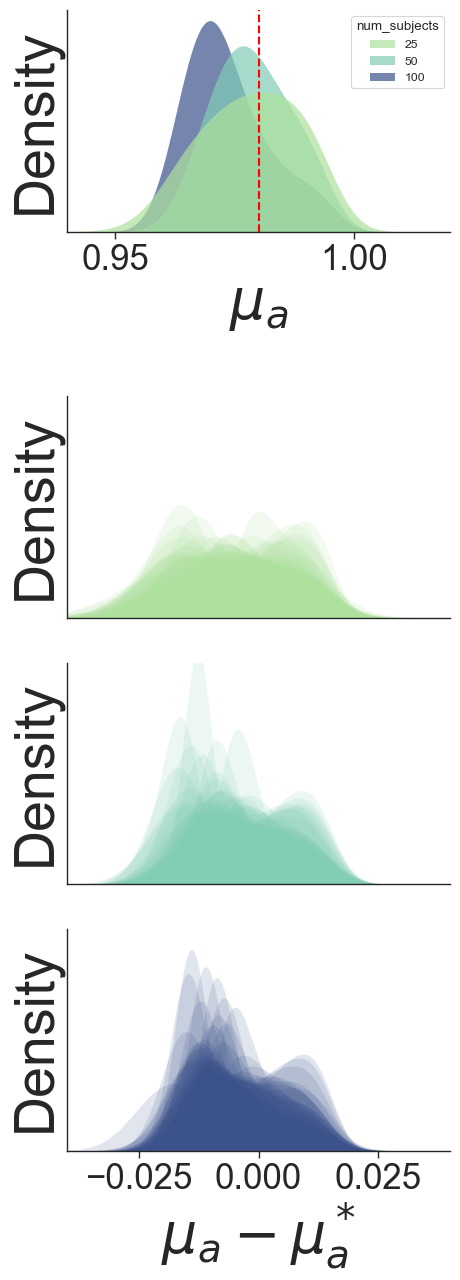

In [451]:
df_temp = df_posterior_mean_subj

# Posteriors mu_a
jnp.array(df_temp[df_temp['dataset']==0]['mean_subject_true_a'])

mean_mu_a = jnp.mean(jnp.array([0.97701627, 0.9767193,0.9790508]))

plot_corrected_posteriors(
    datasets_list=[posterior_samples_mu_a_25, posterior_samples_mu_a_50, posterior_samples_mu_a_100],
    true_params=true_mu_a,#jnp.array(df_posterior_mean_subj['mean_subject_true_a']).reshape(3,50,1),
    x_label_top=r"$\mu_a$",
    x_label=r"$\mu_a-\mu_a^*$",
    x_lim_top=(.94, 1.02),
    x_lim=(-.04, .04),
    y_lim=(0, 120),
    matched_true_param=true_mu_a,
    param='mu_a',
    matched_dataset=[19,19,19], #dataset for 25,50,100 subjects
    filename='corrected_posteriors_mu_a.png'
)


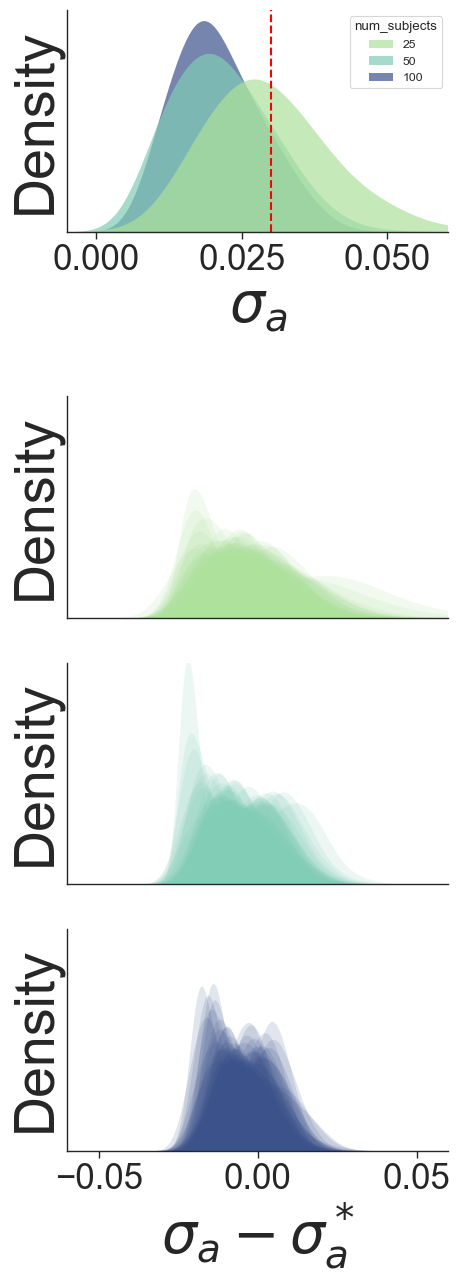

In [453]:
# Posteriors sigma_a
jnp.array(df_temp[df_temp['dataset']==5]['sd_subject_true_a'])

mean_sigma_a = jnp.mean(jnp.array([0.01329772, 0.01440097,0.01437333]))

plot_corrected_posteriors(
    datasets_list=[posterior_samples_sigma_a_25, posterior_samples_sigma_a_50, posterior_samples_sigma_a_100],
    true_params= true_sigma_a, #jnp.array(df_posterior_mean_subj['sd_subject_true_a']).reshape(3,50,1),
    x_label_top=r"$\sigma_a$",
    x_label=r"$\sigma_a-\sigma_a^*$",
    x_lim_top=(-.005, .0605),
    x_lim=(-.06, .06),
    y_lim=(0, 110),
    matched_true_param=true_sigma_a,
    param='sigma_a',
    matched_dataset=[10,10,10],
    filename='corrected_posteriors_sigma_a.png'
)


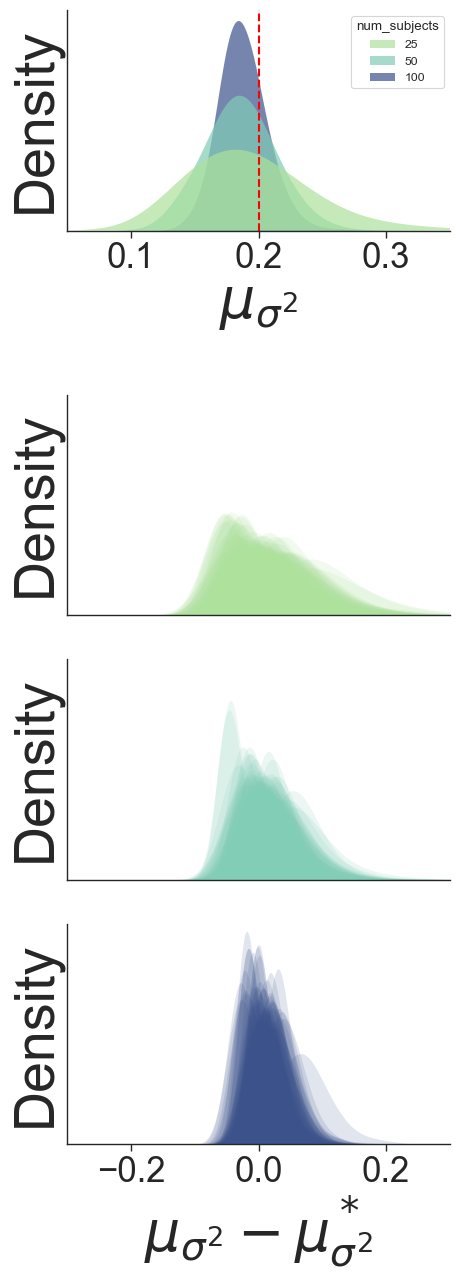

In [458]:
# Posteriors mu_sigmasq
plot_corrected_posteriors(
    datasets_list=[posterior_samples_mu_sigmasq_25, posterior_samples_mu_sigmasq_50, posterior_samples_mu_sigmasq_100],
    true_params=true_mu_sigmasq,
    x_label_top=r"$\mu_{\sigma^2}$",
    x_label=r"$\mu_{\sigma^2}-\mu_{\sigma^2}^*$",
    x_lim_top=(0.05, .35),
    x_lim=(-.3,.3),
    y_lim=(0,24),
    matched_true_param=true_mu_sigmasq,
    param='mu_sigmasq',
    matched_dataset=[12,12,12],
    filename='corrected_posteriors_mu_sigmasq.png'
)


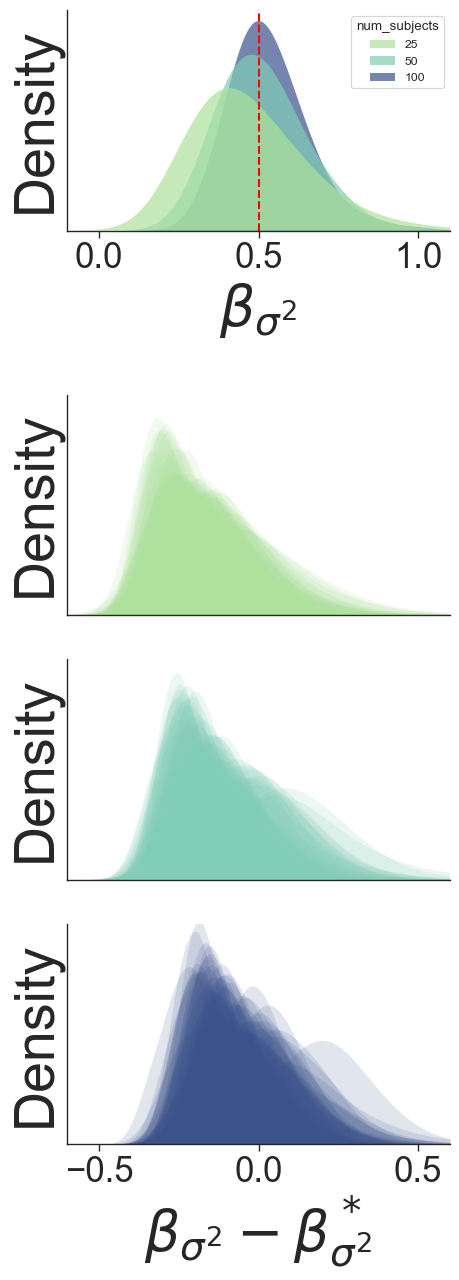

In [459]:
# Posteriors beta_sigmasq
plot_corrected_posteriors(
    datasets_list=[posterior_samples_beta_sigmasq_25, posterior_samples_beta_sigmasq_50, posterior_samples_beta_sigmasq_100],
    true_params=true_beta_sigmasq,
    x_label_top=r"$\beta_{\sigma^2}$",
    x_label=r"$\beta_{\sigma^2}-\beta_{\sigma^2}^*$",
    x_lim_top=(-0.1, 1.1),
    x_lim=(-.6, .6),
    y_lim=(0, 5.5),
    matched_true_param=true_beta_sigmasq,
    param='beta_sigmasq',
    matched_dataset=[33,33,33],
    filename='corrected_posteriors_beta_sigmasq.png'
)


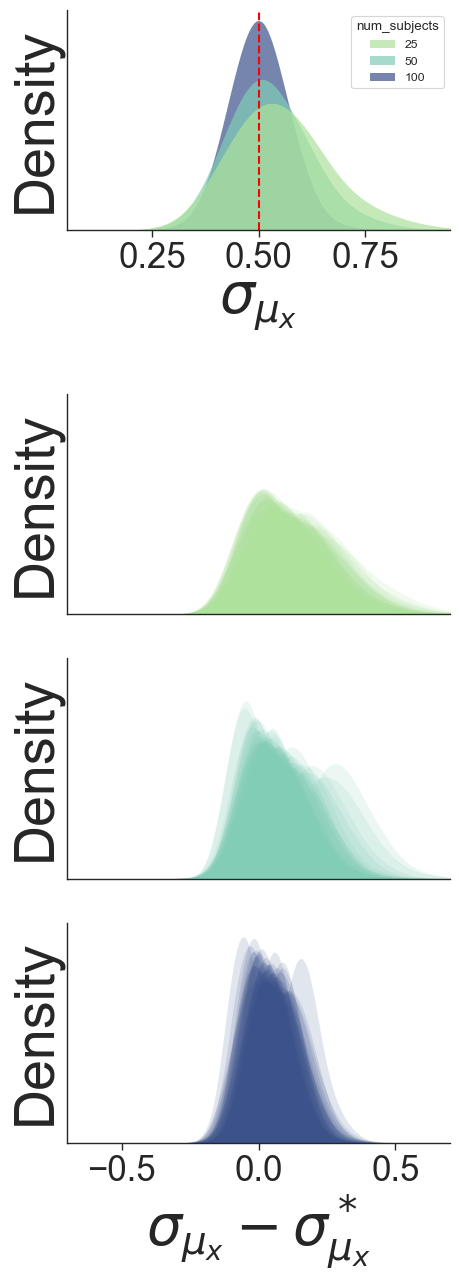

In [462]:
# Posteriors sigma_mu_x
plot_corrected_posteriors(
    datasets_list=[posterior_samples_sigma_mu_x_25, posterior_samples_sigma_mu_x_50, posterior_samples_sigma_mu_x_100],
    true_params= true_sigma_mu_x,
    x_label_top=r"$\sigma_{\mu_x}$",
    x_label=r"$\sigma_{\mu_x}-\sigma_{\mu_x}^*$",
    x_lim_top=(.05, .95),
    x_lim=(-.7, .7),
    y_lim=(0,6.5),
    matched_true_param=true_sigma_mu_x,
    param='sigma_mu_x',
    matched_dataset=[40,40,40],
    filename='corrected_posteriors_sigma_mu_x.png'
)


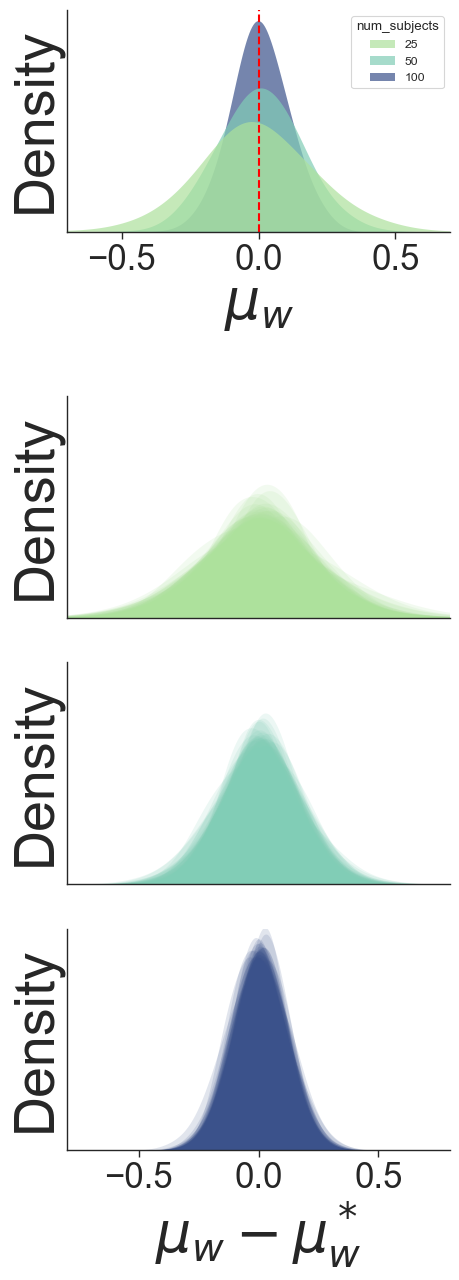

In [464]:
# Posteriors mu_w

plot_corrected_posteriors(
    datasets_list=[jnp.stack(posterior_samples_mu_w_25)[:,:,0], jnp.stack(posterior_samples_mu_w_50)[:,:,0], jnp.stack(posterior_samples_mu_w_100)[:,:,0]],
    true_params=jnp.array(df_posterior_mean_subj['mean_subject_true_w0']).reshape(3,50,1),
    x_label_top=r"$\mu_w$",
    x_label=r"$\mu_w-\mu_{w}^*$",
    x_lim_top=(-.7, .7),
    x_lim=(-.8, .8),
    y_lim=(0, 4.1),
    matched_true_param=0.0,
    param='mu_w',
    matched_dataset=[16,21,16],
    filename='corrected_posteriors_mu_w.png'
)


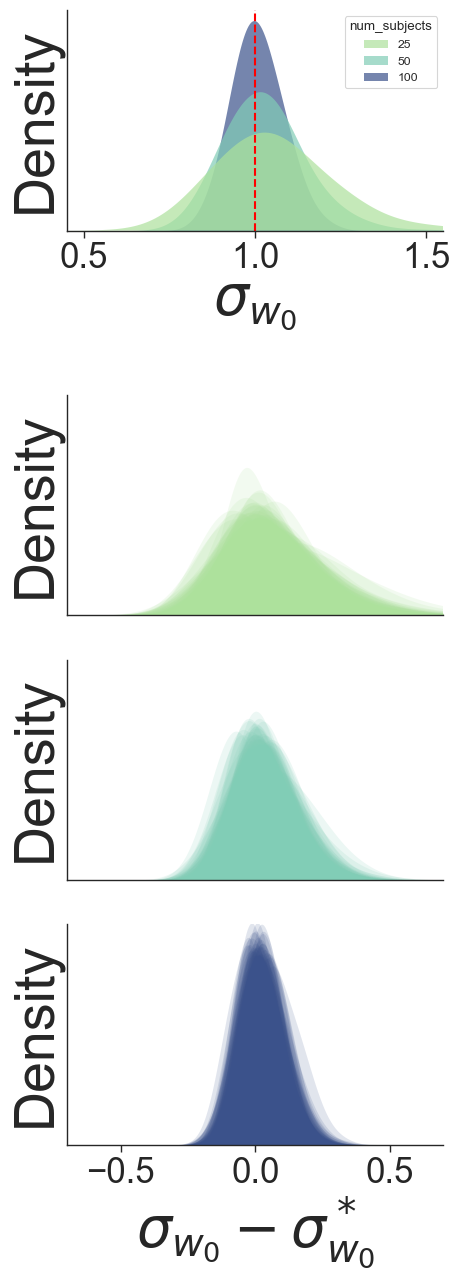

In [469]:

# Posteriors sigma_w
jnp.array(df_posterior_mean_subj[df_posterior_mean_subj['dataset']==27]['sd_subject_true_w0'])

mean_sigma_w = jnp.mean(jnp.array([0.89304733, 0.8982136, 0.89172435]))

plot_corrected_posteriors(
    datasets_list=[jnp.stack(posterior_samples_sigma_w_25)[:,:,0], jnp.stack(posterior_samples_sigma_w_50)[:,:,0], jnp.stack(posterior_samples_sigma_w_100)[:,:,0]],
    true_params=jnp.array(df_posterior_mean_subj['sd_subject_true_w0']).reshape(3,50,1),
    x_label_top=r"$\sigma_{w_0}$",
    x_label=r"$\sigma_{w_0}-\sigma_{w_0}^*$",
    x_lim_top=(.45, 1.55),
    x_lim=(-.7, .7),
    y_lim=(0, 5.5),
    matched_true_param=1.0,
    param='sigma_w',
    matched_dataset=[9,23,3],
    filename='corrected_posteriors_sigma_w.png'
)



In [470]:
"""
Plots with number of trials
"""
# Load in the different dil files
# Because variables within these dil files have the same names we have to rename them
num_subjects=50

file_500trials = file_paths_mapping.get((500, num_subjects))
file_1000trials = file_paths_mapping.get((1000, num_subjects))
file_2500trials = file_paths_mapping.get((2500, num_subjects))
file_5000trials = file_paths_mapping.get((5000, num_subjects))

load_dill_file(file_500trials[0])

posterior_samples_mu_sigmasq_500 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_500 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_500 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_500 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_500 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_500 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_500 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]

load_dill_file(file_1000trials[0])

posterior_samples_mu_sigmasq_1000 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_1000 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_1000 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_1000 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_1000 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_1000 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_1000 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]


for file_path in file_2500trials:
    load_dill_file(file_path)

all_posterior_samples_mu_w = all_posterior_samples_mu_w + all_posterior_samples_mu_w2
all_posterior_samples_sigma_w = all_posterior_samples_sigma_w + all_posterior_samples_sigma_w2
all_posterior_samples_mu_a = all_posterior_samples_mu_a + all_posterior_samples_mu_a2
all_posterior_samples_sigma_a = all_posterior_samples_sigma_a + all_posterior_samples_sigma_a2
all_posterior_samples_sigma_mu_x = all_posterior_samples_sigma_mu_x + all_posterior_samples_sigma_mu_x2
all_posterior_samples_mu_sigmasq = all_posterior_samples_mu_sigmasq + all_posterior_samples_mu_sigmasq2
all_posterior_samples_beta_sigmasq = all_posterior_samples_beta_sigmasq + all_posterior_samples_beta_sigmasq2


posterior_samples_mu_sigmasq_2500 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_2500 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_2500 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_2500 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_2500 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_2500 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_2500 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]


for file_path in file_5000trials:
    load_dill_file(file_path)

all_posterior_samples_mu_w = all_posterior_samples_mu_w + all_posterior_samples_mu_w2 + all_posterior_samples_mu_w3 + all_posterior_samples_mu_w4 + all_posterior_samples_mu_w5
all_posterior_samples_sigma_w = all_posterior_samples_sigma_w + all_posterior_samples_sigma_w2 + all_posterior_samples_sigma_w3 + all_posterior_samples_sigma_w4 + all_posterior_samples_sigma_w5
all_posterior_samples_mu_a = all_posterior_samples_mu_a + all_posterior_samples_mu_a2 + all_posterior_samples_mu_a3 + all_posterior_samples_mu_a4 + all_posterior_samples_mu_a5
all_posterior_samples_sigma_a = all_posterior_samples_sigma_a + all_posterior_samples_sigma_a2 + all_posterior_samples_sigma_a3 + all_posterior_samples_sigma_a4 + all_posterior_samples_sigma_a5
all_posterior_samples_sigma_mu_x = all_posterior_samples_sigma_mu_x + all_posterior_samples_sigma_mu_x2 + all_posterior_samples_sigma_mu_x3 + all_posterior_samples_sigma_mu_x4 + all_posterior_samples_sigma_mu_x5
all_posterior_samples_mu_sigmasq = all_posterior_samples_mu_sigmasq + all_posterior_samples_mu_sigmasq2 + all_posterior_samples_mu_sigmasq3 + all_posterior_samples_mu_sigmasq4 + all_posterior_samples_mu_sigmasq5
all_posterior_samples_beta_sigmasq = all_posterior_samples_beta_sigmasq + all_posterior_samples_beta_sigmasq2 + all_posterior_samples_beta_sigmasq3 + all_posterior_samples_beta_sigmasq4 + all_posterior_samples_beta_sigmasq5

posterior_samples_mu_sigmasq_5000 = jnp.stack(all_posterior_samples_mu_sigmasq)[:,burn_in:]
posterior_samples_beta_sigmasq_5000 = jnp.stack(all_posterior_samples_beta_sigmasq)[:,burn_in:]
posterior_samples_mu_a_5000 = jnp.stack(all_posterior_samples_mu_a)[:,burn_in:]
posterior_samples_sigma_a_5000 = jnp.stack(all_posterior_samples_sigma_a)[:,burn_in:]
posterior_samples_sigma_mu_x_5000 = jnp.stack(all_posterior_samples_sigma_mu_x)[:,burn_in:]
posterior_samples_mu_w_5000 = jnp.stack(all_posterior_samples_mu_w)[:,burn_in:,:]
posterior_samples_sigma_w_5000 = jnp.stack(all_posterior_samples_sigma_w)[:,burn_in:,:]


num_datasets = 50

df_posterior_mean_plotting = pd.concat([data500_posterior_mean, data1000_posterior_mean, data2500_posterior_mean, data5000_posterior_mean], axis=0)
df_posterior_mean_plotting['dataset'] = np.arange(0,num_datasets).tolist() * 4 # 4 levels of number of trials



posterior_mu_a = jnp.array([posterior_samples_mu_a_500,posterior_samples_mu_a_1000,posterior_samples_mu_a_2500,posterior_samples_mu_a_5000]).flatten()
posterior_sigma_a = jnp.array([posterior_samples_sigma_a_500,posterior_samples_sigma_a_1000,posterior_samples_sigma_a_2500,posterior_samples_sigma_a_5000]).flatten()
posterior_mu_sigmasq = jnp.array([posterior_samples_mu_sigmasq_500,posterior_samples_mu_sigmasq_1000,posterior_samples_mu_sigmasq_2500,posterior_samples_mu_sigmasq_5000]).flatten()
posterior_beta_sigmasq = jnp.array([posterior_samples_beta_sigmasq_500,posterior_samples_beta_sigmasq_1000,posterior_samples_beta_sigmasq_2500,posterior_samples_beta_sigmasq_5000]).flatten()
posterior_sigma_mu_x = jnp.array([posterior_samples_sigma_mu_x_500,posterior_samples_sigma_mu_x_1000,posterior_samples_sigma_mu_x_2500,posterior_samples_sigma_mu_x_5000]).flatten()
posterior_mu_w = jnp.array([jnp.stack(posterior_samples_mu_w_500)[:,:,0], jnp.stack(posterior_samples_mu_w_1000)[:,:,0], jnp.stack(posterior_samples_mu_w_2500)[:,:,0], jnp.stack(posterior_samples_mu_w_5000)[:,:,0]]).flatten()
posterior_sigma_w = jnp.array([jnp.stack(posterior_samples_sigma_w_500)[:,:,0], jnp.stack(posterior_samples_sigma_w_1000)[:,:,0], jnp.stack(posterior_samples_sigma_w_2500)[:,:,0], jnp.stack(posterior_samples_sigma_w_5000)[:,:,0]]).flatten()


num_trials = jnp.repeat(jnp.array([500,1000,2500,5000]),50*1000) #50 datasets * 1000 iterations
dataset = jnp.tile(jnp.repeat(jnp.arange(0,num_datasets),1000, axis=0),4)

df_example_post_trials = pd.DataFrame({
        'mu_a': posterior_mu_a,
        'sigma_a': posterior_sigma_a,
        'mu_sigmasq': posterior_mu_sigmasq,
        'beta_sigmasq': posterior_beta_sigmasq,
        'sigma_mu_x': posterior_sigma_mu_x,
        'mu_w': posterior_mu_w,
        'sigma_w': posterior_sigma_w,
        'num_trials': num_trials,
        'dataset': dataset})

df_example_post_trials['num_trials']= pd.Categorical(df_example_post_trials['num_trials'], categories=[500, 1000, 2500, 5000])



In [514]:
colors=['#ADE19C','#81CDB6','#94BBC6','#3b528b']


def plot_corrected_posteriors_trials(datasets_list, true_params, matched_true_param, matched_dataset, x_label, x_label_top, x_lim_top, x_lim, y_lim, param, filename):

    # Create subplots
    fig, axs = plt.subplots(5, 1, figsize=(5, 12), sharex=False)
    
    part1 = df_example_post_trials[(df_example_post_trials['num_trials'] == 500) & (df_example_post_trials['dataset'] == matched_dataset[0])]
    part2 = df_example_post_trials[(df_example_post_trials['num_trials'] == 1000) & (df_example_post_trials['dataset'] == matched_dataset[1])]
    part3 = df_example_post_trials[(df_example_post_trials['num_trials'] == 2500) & (df_example_post_trials['dataset'] == matched_dataset[2])]
    part4 = df_example_post_trials[(df_example_post_trials['num_trials'] == 5000) & (df_example_post_trials['dataset'] == matched_dataset[3])]

    combined = pd.concat([part1, part2, part3, part4], axis=0)
    
    sns.kdeplot(
        data=combined, 
        x=param, 
        hue='num_trials', 
        palette=colors,
        hue_order=[500, 1000, 2500, 5000], 
        ax=axs[0],  # Moved to the top
        bw_adjust=2, fill=True, alpha=0.7, linewidth=0, legend=False
    )
    axs[0].axvline(x=matched_true_param, color='red', linestyle='--')
    axs[0].set_yticks([])
    axs[0].set_xlim(x_lim_top)
    axs[0].yaxis.set_tick_params(size=0)
    axs[0].xaxis.set_tick_params(size=5, labelsize=25)
    axs[0].set_xlabel(x_label_top, size=40)
    axs[0].set_ylabel("Density", size=36)
    
    # Loop through other datasets and corresponding axes
    datasets = jnp.stack([jnp.stack(df) for df in datasets_list])
    
    # Subtract true parameters
    corrected_datasets = datasets - true_params
    
    for i, dataset in enumerate(corrected_datasets):
        # Plot the dataset for specific posterior
        for posterior in dataset:
            sns.kdeplot(
                posterior, bw_adjust=2, ax=axs[i + 1],  # Shift by 1 for the remaining axes
                fill=True, color=colors[i], alpha=0.15, linewidth=0
            )
        axs[i + 1].set_ylabel("Density", size=36)  # Shifted to axs[i + 1]
        axs[i + 1].set_xlim(x_lim)
        axs[i + 1].set_ylim(y_lim)
        axs[i + 1].set_yticks([])
        axs[i + 1].yaxis.set_tick_params(size=0)
        axs[i + 1].xaxis.set_tick_params(size=0)
    
    axs[-1].set_xlabel(x_label, size=40)
    axs[-1].xaxis.set_tick_params(size=5, labelsize=25)
    axs[1].set_xticklabels([]) 
    axs[2].set_xticklabels([]) 
    axs[3].set_xticklabels([]) 
    
    plt.tight_layout()
    # Reduce space between subplots globally
    plt.subplots_adjust(hspace=0.2)  # Uniform spacing for plots (change value as needed)
    
    # Manually adjust the position of the top plot to create more space
    pos = axs[0].get_position()  # Get current position of the top plot
    axs[0].set_position([pos.x0, pos.y0 + 0.1, pos.width, pos.height])  # Move it higher by increasing pos.y0
    

    plt.savefig(filename,transparent=True, bbox_inches='tight', dpi=600)
    plt.show()

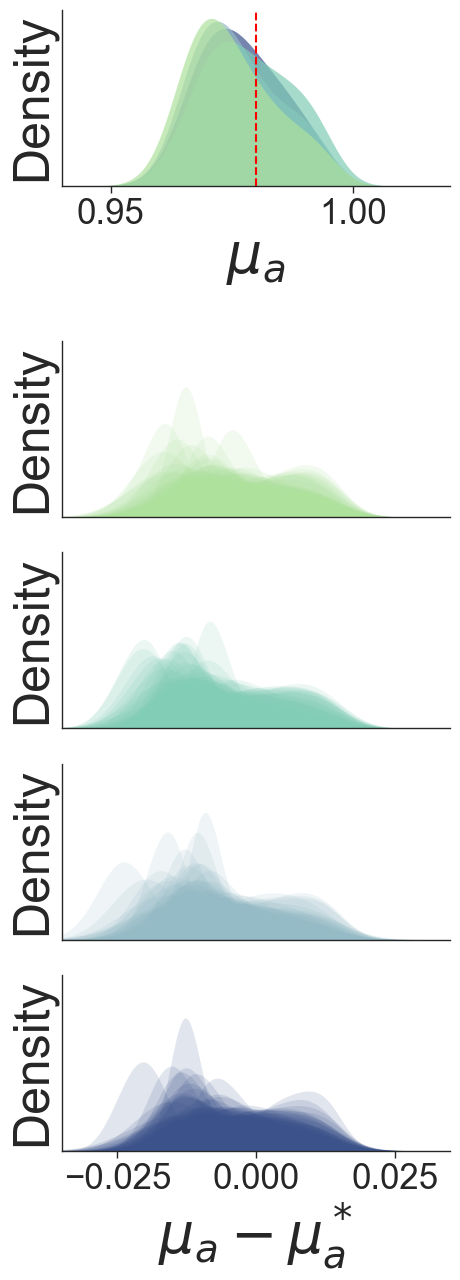

In [524]:
df_temp = df_posterior_mean_plotting

# Posteriors mu_a
plot_corrected_posteriors_trials(
    datasets_list=[posterior_samples_mu_a_500, posterior_samples_mu_a_1000, posterior_samples_mu_a_2500,posterior_samples_mu_a_5000],
    true_params=true_mu_a,#jnp.array(df_posterior_mean_plotting['mean_subject_true_a']).reshape(4,50,1),
    x_label_top=r"$\mu_a$",
    x_label=r"$\mu_a-\mu_a^*$",
    x_lim_top=(.94, 1.02),
    x_lim=(-.035, .035),
    y_lim=(0, 170),
    matched_true_param=true_mu_a,
    param='mu_a',
    matched_dataset=[1,1,1,1], #dataset for 500,1000,2500,5000 trials
    filename='corrected_posteriors_mu_a_trials.png'
)


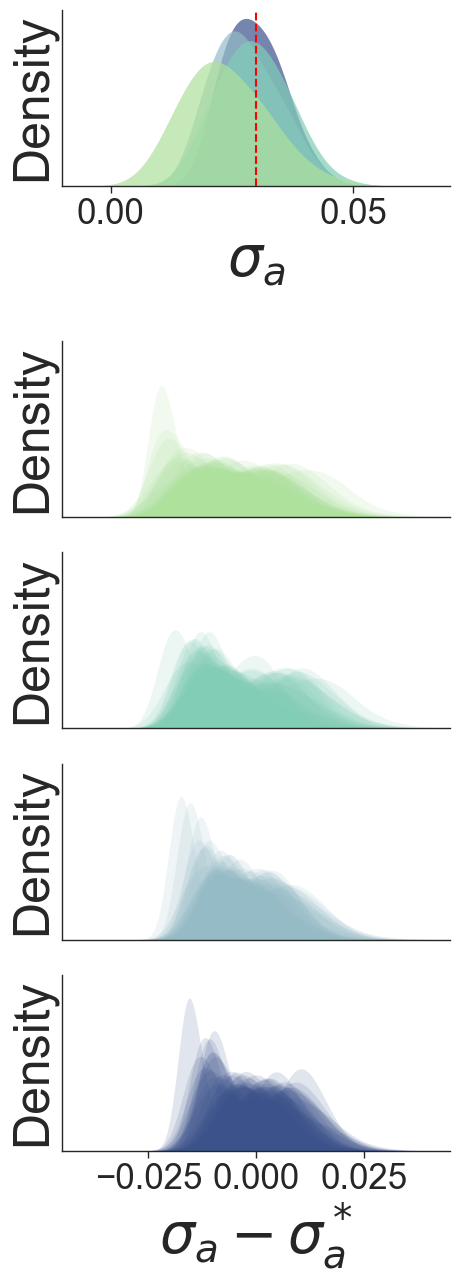

In [526]:

# Posteriors sigma_a
jnp.array(df_temp[df_temp['dataset']==14]['sd_subject_true_a'])

mean_sigma_a = jnp.mean(jnp.array([0.01770392, 0.01770392, 0.01770392, 0.01747185]))

plot_corrected_posteriors_trials(
    datasets_list=[posterior_samples_sigma_a_500, posterior_samples_sigma_a_1000, posterior_samples_sigma_a_2500,posterior_samples_sigma_a_5000],
    true_params=true_sigma_a, #jnp.array(df_posterior_mean_plotting['sd_subject_true_a']).reshape(4,50,1),
    x_label_top=r"$\sigma_a$",
    x_label=r"$\sigma_a-\sigma_a^*$",
    x_lim_top=(-.01, .07),
    x_lim=(-.045, .045),
    y_lim=(0, 150),
    matched_true_param=true_sigma_a,
    param='sigma_a',
    matched_dataset=[1,1,1,1],
    filename='corrected_posteriors_sigma_a_trials.png'
)


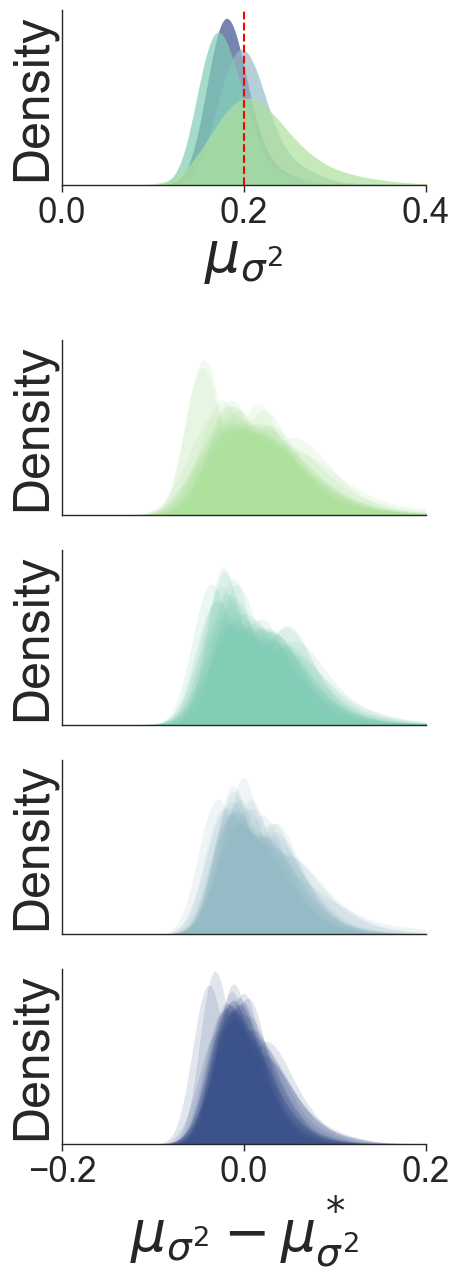

In [516]:
# Posteriors mu_sigmasq
plot_corrected_posteriors_trials(
    datasets_list=[posterior_samples_mu_sigmasq_500, posterior_samples_mu_sigmasq_1000, posterior_samples_mu_sigmasq_2500,posterior_samples_mu_sigmasq_5000],
    true_params=true_mu_sigmasq,
    x_label_top=r"$\mu_{\sigma^2}$",
    x_label=r"$\mu_{\sigma^2}-\mu_{\sigma^2}^*$",
    x_lim_top=(0,.4),
    x_lim=(-.2,.2),
    y_lim=(0,22),
    matched_true_param=true_mu_sigmasq,
    param='mu_sigmasq',
    matched_dataset=[1,1,1,1],
    filename='corrected_posteriors_mu_sigmasq_trials.png'
)


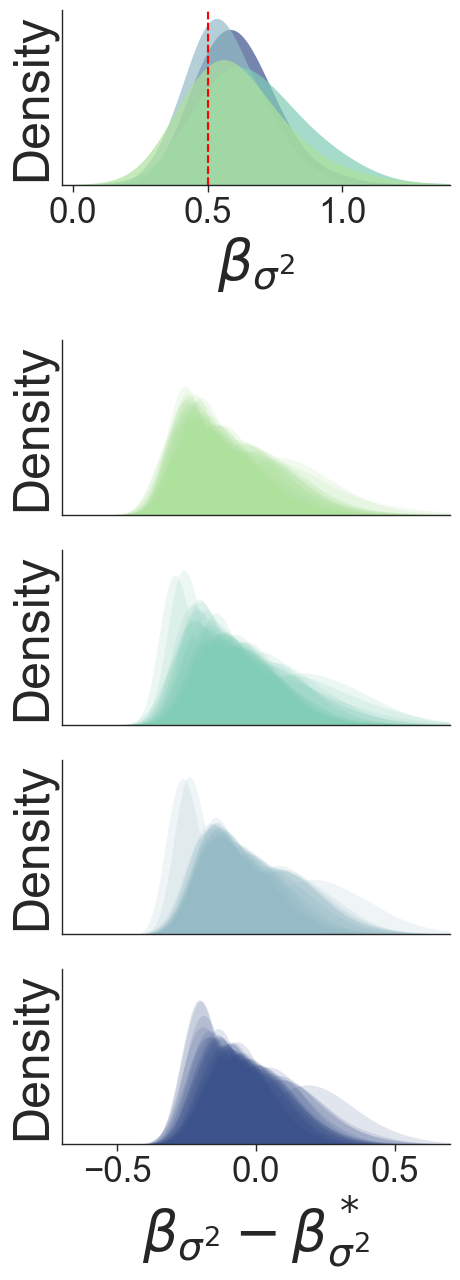

In [517]:
# Posteriors beta_sigmasq
plot_corrected_posteriors_trials(
    datasets_list=[posterior_samples_beta_sigmasq_500, posterior_samples_beta_sigmasq_1000, posterior_samples_beta_sigmasq_2500,posterior_samples_beta_sigmasq_5000],
    true_params=true_beta_sigmasq,
    x_label_top=r"$\beta_{\sigma^2}$",
    x_label=r"$\beta_{\sigma^2}-\beta_{\sigma^2}^*$",
    x_lim_top=(-.04, 1.4),
    x_lim=(-.7, .7),
    y_lim=(0, 7),
    matched_true_param=true_beta_sigmasq,
    param='beta_sigmasq',
    matched_dataset=[15,15,15,15],
    filename='corrected_posteriors_beta_sigmasq_trials.png'
)


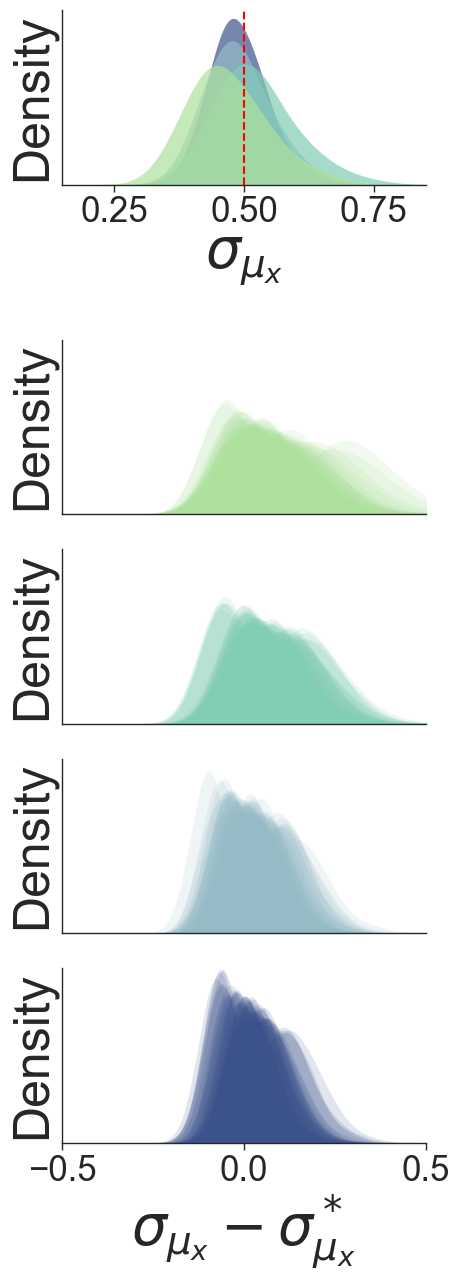

In [518]:
# Posteriors sigma_mu_x
plot_corrected_posteriors_trials(
    datasets_list=[posterior_samples_sigma_mu_x_500, posterior_samples_sigma_mu_x_1000, posterior_samples_sigma_mu_x_2500,posterior_samples_sigma_mu_x_5000],
    true_params= true_sigma_mu_x,
    x_label_top=r"$\sigma_{\mu_x}$",
    x_label=r"$\sigma_{\mu_x}-\sigma_{\mu_x}^*$",
    x_lim_top=(.15, .85),
    x_lim=(-.5, .5),
    y_lim=(0,8),
    matched_true_param=true_sigma_mu_x,
    param='sigma_mu_x',
    matched_dataset=[11,11,11,11],
    filename='corrected_posteriors_sigma_mu_x_trials.png'
)

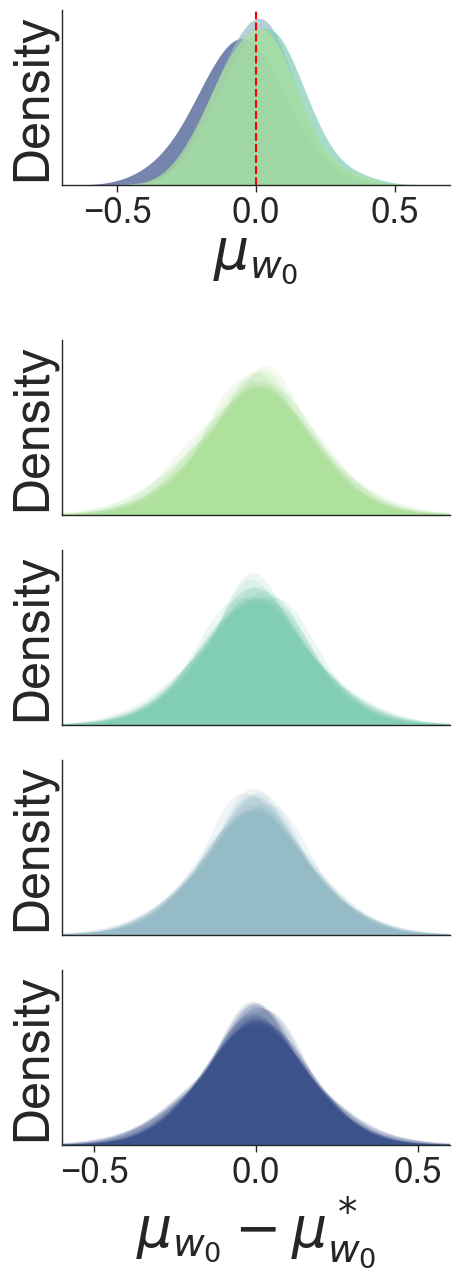

In [519]:
# Posteriors mu_w
plot_corrected_posteriors_trials(
    datasets_list=[jnp.stack(posterior_samples_mu_w_500)[:,:,0], jnp.stack(posterior_samples_mu_w_1000)[:,:,0], jnp.stack(posterior_samples_mu_w_2500)[:,:,0], jnp.stack(posterior_samples_mu_w_5000)[:,:,0]],
    true_params=jnp.array(df_posterior_mean_plotting['mean_subject_true_w0']).reshape(4,50,1),
    x_label_top=r"$\mu_{w_0}$",
    x_label=r"$\mu_{w_0}-\mu_{w_0}^*$",
    x_lim_top=(-.7, .7),
    x_lim=(-.6, .6),
    y_lim=(0, 3.7),
    matched_true_param=0.0,
    param='mu_w',
    matched_dataset=[11,11,11,11],
    filename='corrected_posteriors_mu_w_trials.png'
)


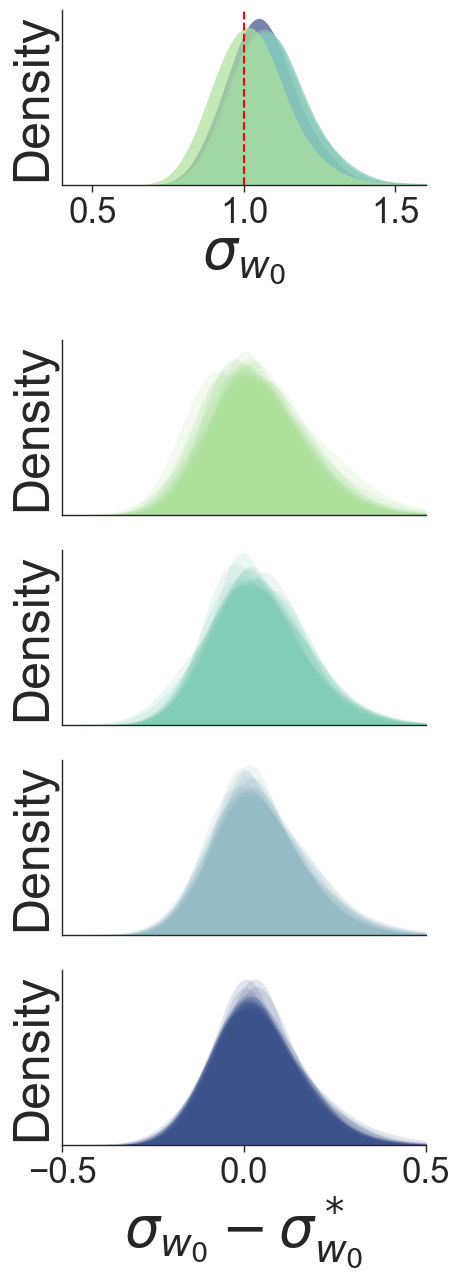

In [521]:
# Posteriors sigma_w

plot_corrected_posteriors_trials(
    datasets_list=[jnp.stack(posterior_samples_sigma_w_500)[:,:,0], jnp.stack(posterior_samples_sigma_w_1000)[:,:,0], jnp.stack(posterior_samples_sigma_w_2500)[:,:,0], jnp.stack(posterior_samples_sigma_w_5000)[:,:,0]],
    true_params=jnp.array(df_posterior_mean_plotting['sd_subject_true_w0']).reshape(4,50,1),
    x_label_top=r"$\sigma_{w_0}$",
    x_label=r"$\sigma_{w_0}-\sigma_{w_0}^*$",
    x_lim_top=(.4, 1.6),
    x_lim=(-.5, .5),
    y_lim=(0, 4.5),
    matched_true_param=1.0,
    param='sigma_w',
    matched_dataset=[23,23,23,23],
    filename='corrected_posteriors_sigma_w_trials.png'
)